In [1]:
# =========================================
# 0) Imports + IO
# =========================================
import os, json, math
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, WhiteKernel

import optuna

# Optional boosters
HAVE_XGB = HAVE_LGBM = HAVE_CAT = False
try:
    import xgboost as xgb
    HAVE_XGB = True
except Exception:
    pass

try:
    import lightgbm as lgb
    HAVE_LGBM = True
except Exception:
    pass

try:
    from catboost import CatBoostRegressor
    HAVE_CAT = True
except Exception:
    pass

DATA_PATH = "data/data.xlsx"  # adjust if needed
data = pd.read_excel(DATA_PATH)

targets_all = ["M_LB", "M_DB"]
feature_cols = [c for c in data.columns if c not in targets_all]

print("Data shape:", data.shape)
print("Features:", feature_cols)
print("Targets:", targets_all)

Data shape: (432, 14)
Features: ['D', 'Bf', 'Bl', 't', 'Lsl', 'Wsl', 'Ssl', 'Bsl', 'N', 'n', 'Fy', 'r']
Targets: ['M_LB', 'M_DB']


In [2]:
# =========================================
# 1) Config
# =========================================
CFG = {
    "random_state": 42,
    "test_size": 0.20,
    "cv_splits": 10,
    "optuna_trials": 40,     # increase to 80–150 for final runs
    "artdir": "./artifacts",
    "models_to_run": [
        # single / baseline
        "ridge", "lasso", "elasticnet", "dt", "knn", "svr", "gpr",
        # ensembles
        "rf", "gbrt", "adaboost",
        # optional gradient boosters
        "xgb", "lgbm", "catboost"
    ],
    "feature_cols": feature_cols
}

os.makedirs(CFG["artdir"], exist_ok=True)

# Filter optional models if not installed
filtered = []
for mk in CFG["models_to_run"]:
    if mk == "xgb" and not HAVE_XGB:
        continue
    if mk == "lgbm" and not HAVE_LGBM:
        continue
    if mk == "catboost" and not HAVE_CAT:
        continue
    filtered.append(mk)
CFG["models_to_run"] = filtered

print("Models to run:", CFG["models_to_run"])

Models to run: ['ridge', 'lasso', 'elasticnet', 'dt', 'knn', 'svr', 'gpr', 'rf', 'gbrt', 'adaboost', 'xgb', 'lgbm', 'catboost']


In [3]:
# =========================================
# 2) Preprocessor (safe)
# =========================================
def preprocessor_for(model_key: str, df: pd.DataFrame):
    """
    Numeric-only pipeline.
    - Always imputes median.
    - Scales for distance/linear/kernel models.
    - No scaling for tree/boosting models (optional but typical).
    """
    num_cols = CFG["feature_cols"]

    needs_scaling = model_key in {"ridge", "lasso", "elasticnet", "knn", "svr", "gpr"}

    steps = [("imputer", SimpleImputer(strategy="median"))]
    if needs_scaling:
        steps.append(("scaler", StandardScaler()))

    num_pipe = Pipeline(steps)
    return ColumnTransformer([("num", num_pipe, num_cols)], remainder="drop")

In [21]:
# =========================================
# 3) Model factory (Optuna-tuned)
# =========================================
def build_model(model_key: str, trial: "optuna.trial.Trial"):
    rs = CFG["random_state"]

    if model_key == "ridge":
        return Ridge(alpha=trial.suggest_float("alpha", 1e-3, 1e3, log=True))

    if model_key == "lasso":
        return Lasso(alpha=trial.suggest_float("alpha", 1e-4, 10.0, log=True),
                     max_iter=8000, random_state=rs)

    if model_key == "elasticnet":
        return ElasticNet(alpha=trial.suggest_float("alpha", 1e-4, 10.0, log=True),
                          l1_ratio=trial.suggest_float("l1_ratio", 0.0, 1.0),
                          max_iter=8000, random_state=rs)

    if model_key == "dt":
        return DecisionTreeRegressor(
            max_depth=trial.suggest_int("max_depth", 2, 40),
            min_samples_split=trial.suggest_int("min_samples_split", 2, 30),
            min_samples_leaf=trial.suggest_int("min_samples_leaf", 1, 20),
            random_state=rs
        )

    if model_key == "knn":
        return KNeighborsRegressor(
            n_neighbors=trial.suggest_int("n_neighbors", 2, 35),
            weights=trial.suggest_categorical("weights", ["uniform", "distance"]),
            p=trial.suggest_int("p", 1, 2)
        )

    if model_key == "rf":
        return RandomForestRegressor(
            n_estimators=trial.suggest_int("n_estimators", 300, 1200, step=100),
            max_depth=trial.suggest_int("max_depth", 3, 40),
            min_samples_split=trial.suggest_int("min_samples_split", 2, 20),
            min_samples_leaf=trial.suggest_int("min_samples_leaf", 1, 10),
            max_features=trial.suggest_float("max_features", 0.3, 1.0),  # valid in new sklearn
            n_jobs=-1,
            random_state=rs
        )

    if model_key == "gbrt":
        return GradientBoostingRegressor(
            n_estimators=trial.suggest_int("n_estimators", 200, 1500, step=100),
            max_depth=trial.suggest_int("max_depth", 2, 6),
            learning_rate=trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
            subsample=trial.suggest_float("subsample", 0.6, 1.0),
            random_state=rs
        )

    if model_key == "adaboost":
        return AdaBoostRegressor(
            n_estimators=trial.suggest_int("n_estimators", 100, 1000, step=50),
            learning_rate=trial.suggest_float("learning_rate", 1e-3, 2.0, log=True),
            random_state=rs
        )

    if model_key == "svr":
        return SVR(
            C=trial.suggest_float("C", 1e-2, 1e3, log=True),
            epsilon=trial.suggest_float("epsilon", 1e-3, 1.0, log=True),
            gamma=trial.suggest_categorical("gamma", ["scale", "auto"]),
            kernel=trial.suggest_categorical("kernel", ["rbf", "poly", "sigmoid"])
        )

    if model_key == "xgb":
        if not HAVE_XGB:
            raise ValueError("xgboost not installed.")
        return xgb.XGBRegressor(
            n_estimators=trial.suggest_int("n_estimators", 300, 2000, step=100),
            max_depth=trial.suggest_int("max_depth", 3, 12),
            learning_rate=trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
            subsample=trial.suggest_float("subsample", 0.5, 1.0),
            colsample_bytree=trial.suggest_float("colsample_bytree", 0.5, 1.0),
            reg_alpha=trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
            reg_lambda=trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
            min_child_weight=trial.suggest_float("min_child_weight", 1e-2, 10.0, log=True),
            tree_method="hist",
            random_state=rs,
            n_jobs=-1
        )

    if model_key == "lgbm":
        if not HAVE_LGBM:
            raise ValueError("lightgbm not installed.")
        return lgb.LGBMRegressor(
            n_estimators=trial.suggest_int("n_estimators", 300, 2000, step=100),
            num_leaves=trial.suggest_int("num_leaves", 15, 255),
            max_depth=trial.suggest_int("max_depth", -1, 32),
            learning_rate=trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
            subsample=trial.suggest_float("subsample", 0.6, 1.0),
            colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 1.0),
            min_child_samples=trial.suggest_int("min_child_samples", 5, 100),
            reg_alpha=trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
            reg_lambda=trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
            random_state=rs,
            n_jobs=-1
        )

    if model_key == "catboost":
        if not HAVE_CAT:
            raise ValueError("catboost not installed.")
        return CatBoostRegressor(
            depth=trial.suggest_int("depth", 4, 10),
            learning_rate=trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
            l2_leaf_reg=trial.suggest_float("l2_leaf_reg", 1.0, 10.0),
            n_estimators=trial.suggest_int("n_estimators", 300, 2000, step=100),
            loss_function="RMSE",
            random_state=rs,
            verbose=False
        )

    if model_key == "gpr":
        length_scale = trial.suggest_float("length_scale", 0.1, 10.0, log=True)
        noise = trial.suggest_float("noise", 1e-6, 1e-1, log=True)
        kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=length_scale) + WhiteKernel(noise_level=noise)
        return GaussianProcessRegressor(kernel=kernel, alpha=0.0, normalize_y=True, random_state=rs)

    raise ValueError(f"Unknown model_key={model_key}")

In [22]:
# ====== DEFINE fit_eval_id() (run this ONCE) ======
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import (
    RandomForestRegressor, GradientBoostingRegressor,
    AdaBoostRegressor, HistGradientBoostingRegressor
)
from sklearn.svm import SVR
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, WhiteKernel

# Optional boosters
HAVE_XGB = HAVE_LGBM = HAVE_CAT = False
try:
    import xgboost as xgb
    HAVE_XGB = True
except Exception:
    pass

try:
    import lightgbm as lgb
    HAVE_LGBM = True
except Exception:
    pass

try:
    from catboost import CatBoostRegressor
    HAVE_CAT = True
except Exception:
    pass

def rmse(y_true, y_pred) -> float:
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def preprocessor_for(model_key: str, feature_cols):
    # scale only for linear / distance / kernel models
    needs_scaling = model_key in {"ridge", "lasso", "elasticnet", "knn", "svr", "gpr"}
    steps = [("imputer", SimpleImputer(strategy="median"))]
    if needs_scaling:
        steps.append(("scaler", StandardScaler()))
    num_pipe = Pipeline(steps)
    return ColumnTransformer([("num", num_pipe, feature_cols)], remainder="drop")

def build_models_all(random_state=42):
    models = {
        "ridge": Ridge(alpha=1.0),
        "lasso": Lasso(alpha=1e-3, max_iter=8000, random_state=random_state),
        "elasticnet": ElasticNet(alpha=1e-3, l1_ratio=0.5, max_iter=8000, random_state=random_state),
        "dt": DecisionTreeRegressor(random_state=random_state),
        "knn": KNeighborsRegressor(n_neighbors=7, weights="distance"),
        "svr": SVR(C=100.0, epsilon=0.01, gamma="scale", kernel="rbf"),
        "gpr": GaussianProcessRegressor(
            kernel=C(1.0, (1e-3, 1e3)) * RBF(length_scale=1.0) + WhiteKernel(noise_level=1e-3),
            normalize_y=True,
            random_state=random_state
        ),
        "rf": RandomForestRegressor(
            n_estimators=600, max_features="sqrt", n_jobs=-1, random_state=random_state
        ),
        "gbrt": GradientBoostingRegressor(random_state=random_state),
        "histgbr": HistGradientBoostingRegressor(random_state=random_state),
        "adaboost": AdaBoostRegressor(random_state=random_state),
    }

    if HAVE_XGB:
        models["xgb"] = xgb.XGBRegressor(
            n_estimators=800, max_depth=6, learning_rate=0.05,
            subsample=0.9, colsample_bytree=0.9,
            reg_alpha=0.0, reg_lambda=1.0,
            tree_method="hist", random_state=random_state, n_jobs=-1
        )
    if HAVE_LGBM:
        models["lgbm"] = lgb.LGBMRegressor(
            n_estimators=800, learning_rate=0.05,
            subsample=0.9, colsample_bytree=0.9,
            random_state=random_state, n_jobs=-1
        )
    if HAVE_CAT:
        models["catboost"] = CatBoostRegressor(
            depth=8, learning_rate=0.05, n_estimators=800,
            loss_function="RMSE", random_state=random_state, verbose=False
        )

    return models

def fit_eval_id(X, y, feature_cols, test_size=0.2, random_state=42):
    """
    Train/evaluate ALL models on one fixed ID split.
    Returns: (results_table, fitted_pipelines, splits_dict)
    """
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )

    rows, fitted = [], {}
    for name, model in build_models_all(random_state).items():
        pre = preprocessor_for(name, feature_cols)
        pipe = Pipeline([("preprocessor", pre), ("model", model)])
        pipe.fit(X_train, y_train)
        yhat = pipe.predict(X_test)

        rows.append({
            "model": name,
            "MAE": float(mean_absolute_error(y_test, yhat)),
            "RMSE": rmse(y_test, yhat),
            "R2": float(r2_score(y_test, yhat)),
        })
        fitted[name] = pipe

    res = pd.DataFrame(rows).sort_values("MAE").reset_index(drop=True)
    splits = {"X_train": X_train, "X_test": X_test, "y_train": y_train, "y_test": y_test}
    return res, fitted, splits

print("[ok] fit_eval_id() is now defined.")

[ok] fit_eval_id() is now defined.


In [5]:
# =========================================
# 4) Utilities
# =========================================
def rmse(y_true, y_pred) -> float:
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def tune_and_eval_one_target(target_col: str):
    X = data[CFG["feature_cols"]].copy()
    y = data[target_col].astype(float).copy()

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=CFG["test_size"], random_state=CFG["random_state"]
    )

    results = {}
    best_pipes = {}

    for model_key in CFG["models_to_run"]:
        print(f"\n=== Tuning {model_key.upper()} for {target_col} ===")

        def objective(trial):
            model = build_model(model_key, trial)
            preproc = preprocessor_for(model_key, df=data)
            pipe = Pipeline([("preprocessor", preproc), ("model", model)])

            cv = KFold(n_splits=CFG["cv_splits"], shuffle=True, random_state=CFG["random_state"])
            scores = cross_val_score(
                pipe, X_train, y_train,
                scoring="neg_root_mean_squared_error",
                cv=cv, n_jobs=-1
            )
            return -float(np.mean(scores))  # minimize RMSE

        study = optuna.create_study(direction="minimize", study_name=f"{model_key}_{target_col}")
        study.optimize(objective, n_trials=CFG["optuna_trials"], show_progress_bar=False)

        best_model = build_model(model_key, study.best_trial)
        preproc = preprocessor_for(model_key, df=data)
        best_pipe = Pipeline([("preprocessor", preproc), ("model", best_model)])
        best_pipe.fit(X_train, y_train)

        y_pred = best_pipe.predict(X_test)

        results[model_key] = {
            "rmse": rmse(y_test, y_pred),
            "mae": float(mean_absolute_error(y_test, y_pred)),
            "r2": float(r2_score(y_test, y_pred)),
            "best_params": study.best_trial.params
        }
        best_pipes[model_key] = best_pipe

    # Save results
    out_json = os.path.join(CFG["artdir"], f"results_{target_col}.json")
    out_csv  = os.path.join(CFG["artdir"], f"results_{target_col}.csv")

    with open(out_json, "w") as f:
        json.dump(results, f, indent=2)

    pd.DataFrame(results).T.sort_values("rmse").to_csv(out_csv, index=True)

    print(f"\n[done] {target_col}: saved {out_json} and {out_csv}")
    return results, best_pipes

In [6]:
# =========================================
# 5) Run for BOTH targets (M_LB and M_DB)
# =========================================
all_results = {}
all_best_pipes = {}

for tgt in ["M_LB", "M_DB"]:
    res, pipes = tune_and_eval_one_target(tgt)
    all_results[tgt] = res
    all_best_pipes[tgt] = pipes

# quick leaderboard
for tgt in all_results:
    print("\n=== Leaderboard (lowest RMSE) for", tgt, "===")
    df_res = pd.DataFrame(all_results[tgt]).T.sort_values("rmse")
    display(df_res[["rmse", "mae", "r2"]].head(10))

[I 2026-03-06 16:29:57,529] A new study created in memory with name: ridge_M_LB



=== Tuning RIDGE for M_LB ===


[I 2026-03-06 16:30:03,123] Trial 0 finished with value: 6.082085738816052 and parameters: {'alpha': 495.2372727569729}. Best is trial 0 with value: 6.082085738816052.
[I 2026-03-06 16:30:03,188] Trial 1 finished with value: 4.033291756088787 and parameters: {'alpha': 91.8238954481189}. Best is trial 1 with value: 4.033291756088787.
[I 2026-03-06 16:30:03,236] Trial 2 finished with value: 3.775009212966674 and parameters: {'alpha': 4.380219360611655}. Best is trial 2 with value: 3.775009212966674.
[I 2026-03-06 16:30:03,283] Trial 3 finished with value: 3.7785497145242517 and parameters: {'alpha': 0.02000015535532205}. Best is trial 2 with value: 3.775009212966674.
[I 2026-03-06 16:30:03,335] Trial 4 finished with value: 3.7784687770223186 and parameters: {'alpha': 0.08799664502349105}. Best is trial 2 with value: 3.775009212966674.
[I 2026-03-06 16:30:03,429] Trial 5 finished with value: 3.7769628231045203 and parameters: {'alpha': 1.5219686958551257}. Best is trial 2 with value: 3.77


=== Tuning LASSO for M_LB ===


[I 2026-03-06 16:30:06,168] Trial 3 finished with value: 3.9519306706328576 and parameters: {'alpha': 0.7327124698358558}. Best is trial 1 with value: 3.7706985663807777.
[I 2026-03-06 16:30:06,216] Trial 4 finished with value: 7.054181496521082 and parameters: {'alpha': 3.5316116719015618}. Best is trial 1 with value: 3.7706985663807777.
[I 2026-03-06 16:30:06,273] Trial 5 finished with value: 3.7784126781184084 and parameters: {'alpha': 0.0007504552215812825}. Best is trial 1 with value: 3.7706985663807777.
[I 2026-03-06 16:30:06,327] Trial 6 finished with value: 10.834531002973346 and parameters: {'alpha': 8.884475092642482}. Best is trial 1 with value: 3.7706985663807777.
[I 2026-03-06 16:30:06,379] Trial 7 finished with value: 3.7684244955349113 and parameters: {'alpha': 0.05138139748283336}. Best is trial 7 with value: 3.7684244955349113.
[I 2026-03-06 16:30:06,442] Trial 8 finished with value: 3.7764191185009066 and parameters: {'alpha': 0.008855384318435782}. Best is trial 7 wi

...

[I 2026-03-06 17:00:16,570] Trial 33 finished with value: 0.21613082600855452 and parameters: {'depth': 6, 'learning_rate': 0.16694458537517154, 'l2_leaf_reg': 7.019956966831319, 'n_estimators': 600}. Best is trial 28 with value: 0.13180966565923496.
[I 2026-03-06 17:00:18,079] Trial 34 finished with value: 0.12957700319536342 and parameters: {'depth': 5, 'learning_rate': 0.29991039712890605, 'l2_leaf_reg': 6.100391985181993, 'n_estimators': 500}. Best is trial 34 with value: 0.12957700319536342.
[I 2026-03-06 17:00:19,882] Trial 35 finished with value: 0.25580150239195865 and parameters: {'depth': 6, 'learning_rate': 0.2967568549601157, 'l2_leaf_reg': 6.195027835535498, 'n_estimators': 500}. Best is trial 34 with value: 0.12957700319536342.
[I 2026-03-06 17:00:21,189] Trial 36 finished with value: 0.27364470847273076 and parameters: {'depth': 7, 'learning_rate': 0.22640880839467256, 'l2_leaf_reg': 8.74644520951277, 'n_estimators': 300}. Best is trial 34 with value: 0.12957700319536342


[done] M_DB: saved ./artifacts\results_M_DB.json and ./artifacts\results_M_DB.csv

=== Leaderboard (lowest RMSE) for M_LB ===


,rmse,mae,r2
xgb,0.092624,0.065732,0.999942
gbrt,0.098298,0.066198,0.999935
catboost,0.098382,0.070373,0.999935
lgbm,0.104605,0.078608,0.999926
gpr,0.112974,0.082704,0.999914
svr,0.177238,0.121846,0.999788
rf,0.22493,0.153323,0.999658
dt,0.246267,0.157803,0.99959
knn,1.977157,1.415295,0.973574
adaboost,2.214881,1.898878,0.966837



=== Leaderboard (lowest RMSE) for M_DB ===


,rmse,mae,r2
catboost,0.266203,0.089183,0.99928
gbrt,0.285287,0.091952,0.999173
xgb,0.290653,0.114747,0.999142
rf,0.300206,0.171455,0.999084
lgbm,0.306545,0.116578,0.999045
svr,0.342444,0.154086,0.998809
gpr,0.35221,0.20008,0.99874
dt,0.385634,0.217387,0.998489
knn,1.500157,1.092767,0.977138
adaboost,1.666349,1.373374,0.971792


In [17]:
import os, json
import numpy as np
import pandas as pd
import joblib

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ---- assumes these exist from earlier in your notebook ----
# data (DataFrame), CFG (dict), build_model(model_key, trial_or_params), preprocessor_for(model_key, df=data)

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def build_model_from_params(model_key: str, params: dict):
    """
    Rebuild models using stored best params (NO Optuna trial).
    Mirrors your build_model() but reads values from params dict.
    """
    rs = CFG["random_state"]

    # ------- single models -------
    if model_key == "ridge":
        from sklearn.linear_model import Ridge
        return Ridge(alpha=float(params["alpha"]))

    if model_key == "lasso":
        from sklearn.linear_model import Lasso
        return Lasso(alpha=float(params["alpha"]), max_iter=8000, random_state=rs)

    if model_key == "elasticnet":
        from sklearn.linear_model import ElasticNet
        return ElasticNet(alpha=float(params["alpha"]), l1_ratio=float(params["l1_ratio"]),
                          max_iter=8000, random_state=rs)

    if model_key == "dt":
        from sklearn.tree import DecisionTreeRegressor
        return DecisionTreeRegressor(
            max_depth=int(params["max_depth"]),
            min_samples_split=int(params["min_samples_split"]),
            min_samples_leaf=int(params["min_samples_leaf"]),
            random_state=rs
        )

    if model_key == "knn":
        from sklearn.neighbors import KNeighborsRegressor
        return KNeighborsRegressor(
            n_neighbors=int(params["n_neighbors"]),
            weights=params["weights"],
            p=int(params["p"])
        )

    if model_key == "svr":
        from sklearn.svm import SVR
        return SVR(
            C=float(params["C"]),
            epsilon=float(params["epsilon"]),
            gamma=params["gamma"],
            kernel=params["kernel"]
        )

    if model_key == "gpr":
        from sklearn.gaussian_process import GaussianProcessRegressor
        from sklearn.gaussian_process.kernels import RBF, ConstantKernel as Ck, WhiteKernel
        length_scale = float(params["length_scale"])
        noise = float(params["noise"])
        kernel = Ck(1.0, (1e-3, 1e3)) * RBF(length_scale=length_scale) + WhiteKernel(noise_level=noise)
        return GaussianProcessRegressor(kernel=kernel, alpha=0.0, normalize_y=True, random_state=rs)

    # ------- ensembles -------
    if model_key == "rf":
        from sklearn.ensemble import RandomForestRegressor
        return RandomForestRegressor(
            n_estimators=int(params["n_estimators"]),
            max_depth=int(params["max_depth"]),
            min_samples_split=int(params["min_samples_split"]),
            min_samples_leaf=int(params["min_samples_leaf"]),
            max_features=float(params["max_features"]),
            n_jobs=-1,
            random_state=rs
        )

    if model_key == "gbrt":
        from sklearn.ensemble import GradientBoostingRegressor
        return GradientBoostingRegressor(
            n_estimators=int(params["n_estimators"]),
            max_depth=int(params["max_depth"]),
            learning_rate=float(params["learning_rate"]),
            subsample=float(params["subsample"]),
            random_state=rs
        )

    if model_key == "adaboost":
        from sklearn.ensemble import AdaBoostRegressor
        return AdaBoostRegressor(
            n_estimators=int(params["n_estimators"]),
            learning_rate=float(params["learning_rate"]),
            random_state=rs
        )

    # ------- optional boosters -------
    if model_key == "xgb":
        import xgboost as xgb
        return xgb.XGBRegressor(
            **{k: (int(v) if k in {"n_estimators","max_depth"} else float(v) if isinstance(v,(int,float)) else v)
               for k,v in params.items()},
            tree_method="hist",
            random_state=rs,
            n_jobs=-1
        )

    if model_key == "lgbm":
        import lightgbm as lgb
        return lgb.LGBMRegressor(
            **params,
            random_state=rs,
            n_jobs=-1
        )

    if model_key == "catboost":
        from catboost import CatBoostRegressor
        return CatBoostRegressor(
            **params,
            loss_function="RMSE",
            random_state=rs,
            verbose=False
        )

    raise ValueError(f"Unknown model_key={model_key}")


def train_best_models_for_target(target_col: str, top_k: int = 5):
    # Load previously tuned results
    res_json = os.path.join(CFG["artdir"], f"results_{target_col}.json")
    res_csv  = os.path.join(CFG["artdir"], f"results_{target_col}.csv")

    if not os.path.exists(res_json) or not os.path.exists(res_csv):
        raise FileNotFoundError(f"Missing {res_json} or {res_csv}. Run tuning once first.")

    with open(res_json, "r") as f:
        stored = json.load(f)   # dict[model_key] -> metrics + best_params

    leaderboard = pd.read_csv(res_csv, index_col=0)  # model_key as index
    leaderboard = leaderboard.sort_values("rmse").head(top_k)

    # Fixed ID split
    X = data[CFG["feature_cols"]].copy()
    y = data[target_col].astype(float).copy()
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=CFG["test_size"], random_state=CFG["random_state"]
    )

    final_rows = []
    fitted_models = {}

    for model_key in leaderboard.index.tolist():
        params = stored[model_key]["best_params"]
        model = build_model_from_params(model_key, params)
        pre = preprocessor_for(model_key, df=data)
        pipe = Pipeline([("preprocessor", pre), ("model", model)])

        pipe.fit(X_train, y_train)
        yhat = pipe.predict(X_test)

        final_rows.append({
            "target": target_col,
            "model": model_key,
            "MAE": float(mean_absolute_error(y_test, yhat)),
            "RMSE": rmse(y_test, yhat),
            "R2": float(r2_score(y_test, yhat)),
            "best_params": json.dumps(params)
        })
        fitted_models[model_key] = pipe

    final_df = pd.DataFrame(final_rows).sort_values("RMSE").reset_index(drop=True)

    # Save trained pipelines
    out_models = os.path.join(CFG["artdir"], f"final_models_{target_col}.joblib")
    joblib.dump(fitted_models, out_models)

    out_final = os.path.join(CFG["artdir"], f"final_metrics_{target_col}.csv")
    final_df.to_csv(out_final, index=False)

    print("Saved:", out_models)
    print("Saved:", out_final)
    return final_df, fitted_models


# ---- Run for both targets ----
for tgt in ["M_LB", "M_DB"]:
    print("\n==== Training best models for", tgt, "====")
    final_df, fitted = train_best_models_for_target(tgt, top_k=5)
    display(final_df)


==== Training best models for M_LB ====


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000082 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 32
[LightGBM] [Info] Number of data points in the train set: 345, number of used features: 9
[LightGBM] [Info] Start training from score 16.934572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

Saved: ./artifacts\final_models_M_LB.joblib
Saved: ./artifacts\final_metrics_M_LB.csv


,target,model,MAE,RMSE,R2,best_params
0,M_LB,xgb,0.065732,0.092624,0.999942,"{""n_estimators"": 1300, ""max_depth"": 5, ""learni..."
1,M_LB,gbrt,0.066198,0.098298,0.999935,"{""n_estimators"": 600, ""max_depth"": 6, ""learnin..."
2,M_LB,catboost,0.070373,0.098382,0.999935,"{""depth"": 4, ""learning_rate"": 0.17563264803639..."
3,M_LB,lgbm,0.078608,0.104605,0.999926,"{""n_estimators"": 1000, ""num_leaves"": 97, ""max_..."
4,M_LB,gpr,0.082704,0.112974,0.999914,"{""length_scale"": 0.9427877924880141, ""noise"": ..."


...

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Saved: ./artifacts\final_models_M_DB.joblib
Saved: ./artifacts\final_metrics_M_DB.csv


,target,model,MAE,RMSE,R2,best_params
0,M_DB,catboost,0.089183,0.266203,0.999280,"{""depth"": 5, ""learning_rate"": 0.29991039712890..."
1,M_DB,gbrt,0.091952,0.285287,0.999173,"{""n_estimators"": 1200, ""max_depth"": 5, ""learni..."
2,M_DB,xgb,0.114747,0.290653,0.999142,"{""n_estimators"": 600, ""max_depth"": 4, ""learnin..."
3,M_DB,rf,0.171455,0.300206,0.999084,"{""n_estimators"": 700, ""max_depth"": 40, ""min_sa..."
4,M_DB,lgbm,0.116578,0.306545,0.999045,"{""n_estimators"": 1600, ""num_leaves"": 255, ""max..."


In [18]:
import numpy as np
from sklearn.model_selection import train_test_split

def choose_group_holdout(series, min_frac=0.12, max_frac=0.35, target_frac=0.20):
    """
    Choose a discrete value to hold out for OOD testing.
    Prefers groups with fraction close to target_frac within [min_frac, max_frac].
    Deterministic tie-breaks.
    """
    vc = series.value_counts(dropna=True)
    n = len(series)
    candidates = []
    for val, cnt in vc.items():
        frac = cnt / n
        if min_frac <= frac <= max_frac:
            # tie-break: closer to target, then larger cnt, then stable string repr
            candidates.append((abs(frac - target_frac), -int(cnt), str(val), val, int(cnt), float(frac)))

    if candidates:
        candidates.sort()
        _, _, _, val, cnt, frac = candidates[0]
        return val, cnt, frac

    # fallback: most frequent value (deterministic)
    val = vc.index[0]
    cnt = int(vc.iloc[0])
    frac = cnt / n
    return val, cnt, frac


def _conformal_quantile(resid, alpha):
    """
    Split conformal quantile:
      q = k-th order statistic where k = ceil((n+1)*(1-alpha)).
    Uses order-statistic behaviour ('higher') without NumPy-version issues.
    """
    resid = np.asarray(resid, dtype=float)
    resid = resid[np.isfinite(resid)]
    n = resid.size
    if n == 0:
        return np.nan
    k = int(np.ceil((n + 1) * (1 - alpha)))  # 1..n+1
    k = min(max(k, 1), n)                    # clamp to [1, n]
    return float(np.partition(resid, k - 1)[k - 1])


def split_conformal_intervals(model_pipe, X_train, y_train, X_test,
                              alpha=0.10, calib_size=0.20, random_state=42):
    """
    Split conformal intervals:
      - split X_train into fit + calibration
      - fit model on fit subset
      - compute residual quantile on calibration
      - produce intervals on X_test
    """
    X_tr, X_cal, y_tr, y_cal = train_test_split(
        X_train, y_train, test_size=calib_size, random_state=random_state
    )
    model_pipe.fit(X_tr, y_tr)

    pred_cal = model_pipe.predict(X_cal)
    resid = np.abs(np.asarray(y_cal) - np.asarray(pred_cal))
    q = _conformal_quantile(resid, alpha)

    pred_test = model_pipe.predict(X_test)
    lo = pred_test - q
    hi = pred_test + q
    return pred_test, lo, hi, q


def ood_split_geometry(df, q=0.15):
    """
    OOD-Geometry: hold out tail regions of slenderness proxy D/t.
    """
    if "D" not in df.columns or "t" not in df.columns:
        raise ValueError("Need columns D and t for geometry OOD split.")
    slender = (df["D"].astype(float) / df["t"].astype(float))
    lo = float(slender.quantile(q))
    hi = float(slender.quantile(1 - q))
    is_test = (slender <= lo) | (slender >= hi)

    meta = {
        "scenario": "OOD-Geometry",
        "proxy": "D/t",
        "q": float(q),
        "lo": lo,
        "hi": hi,
        "n_test": int(is_test.sum()),
        "test_frac": float(is_test.mean())
    }
    return is_test, meta


def ood_split_group(df, colname, min_frac=0.12, max_frac=0.35, target_frac=0.20):
    """
    OOD group split: hold out one discrete group in colname.
    """
    if colname not in df.columns:
        raise ValueError(f"Need column {colname} for group OOD split.")
    val, cnt, frac = choose_group_holdout(df[colname], min_frac=min_frac, max_frac=max_frac, target_frac=target_frac)
    is_test = (df[colname] == val)

    meta = {
        "scenario": f"OOD-{colname}",
        "col": colname,
        "held_out": val,
        "n_test": int(cnt),
        "test_frac": float(frac)
    }
    return is_test, meta

In [23]:
# ====== SETUP + In-distribution (ID) evaluation (FIXED) ======
import os
import numpy as np
import pandas as pd

DATA_PATH = "data/data.xlsx"   # adjust if needed
df = pd.read_excel(DATA_PATH)

targets = ["M_LB", "M_DB"]
X_cols = [c for c in df.columns if c not in targets]
RANDOM_STATE = 42

X = df[X_cols].copy()
id_results = {}

for t in targets:
    y = df[t].astype(float).copy()
    res, fitted, splits = fit_eval_id(X, y, X_cols, test_size=0.2, random_state=RANDOM_STATE)
    id_results[t] = {"table": res, "models": fitted, "splits": splits}
    print(f"\nID results for {t} (sorted by MAE):")
    display(res)

os.makedirs("outputs", exist_ok=True)
for t in targets:
    out_csv = f"outputs/id_results_{t}.csv"
    id_results[t]["table"].to_csv(out_csv, index=False)
    print("Saved:", out_csv)

C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000087 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 32
[LightGBM] [Info] Number of data points in the train set: 345, number of used features: 9
[LightGBM] [Info] Start training from score 16.934572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes


ID results for M_LB (sorted by MAE):


,model,MAE,RMSE,R2
0,xgb,0.062104,0.091434,0.999943
1,gpr,0.082704,0.112974,0.999914
2,lgbm,0.094530,0.121067,0.999901
3,dt,0.117319,0.169308,0.999806
4,svr,0.155174,0.251219,0.999573
5,gbrt,0.177899,0.257343,0.999552
6,catboost,0.202915,0.368802,0.999081
7,histgbr,0.342213,0.432976,0.998733
8,rf,1.010532,1.278568,0.988949
9,adaboost,2.092895,2.618620,0.953645


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000085 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 32
[LightGBM] [Info] Number of data points in the train set: 345, number of used features: 9
[LightGBM] [Info] Start training from score 14.012819
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes


ID results for M_DB (sorted by MAE):


,model,MAE,RMSE,R2
0,xgb,0.106837,0.263438,0.999295
1,catboost,0.135107,0.245306,0.999389
2,svr,0.154253,0.296851,0.999105
3,lgbm,0.169208,0.305630,0.999051
4,gpr,0.200080,0.352210,0.998740
5,dt,0.200567,0.373886,0.998580
6,gbrt,0.242415,0.350241,0.998754
7,histgbr,0.361029,0.498644,0.997474
8,rf,0.808547,1.021300,0.989404
9,adaboost,1.538799,1.835023,0.965793


Saved: outputs/id_results_M_LB.csv
Saved: outputs/id_results_M_DB.csv


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


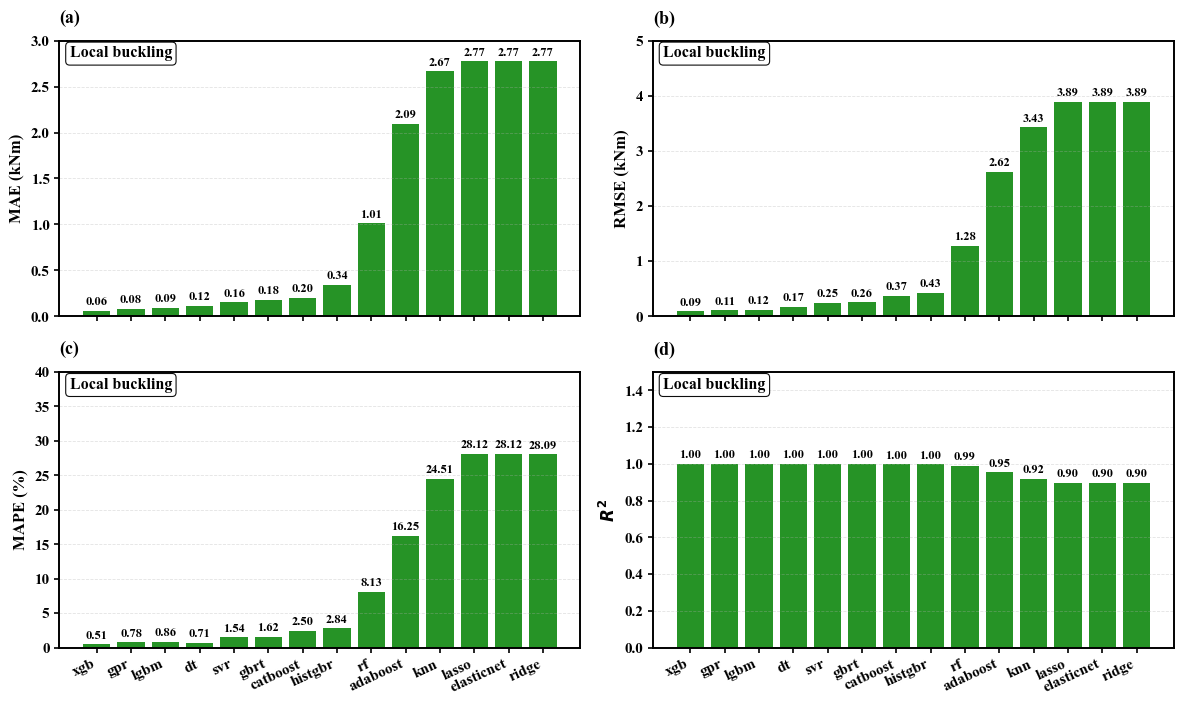

Saved: figures/id_grid_2x2_M_LB.png


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


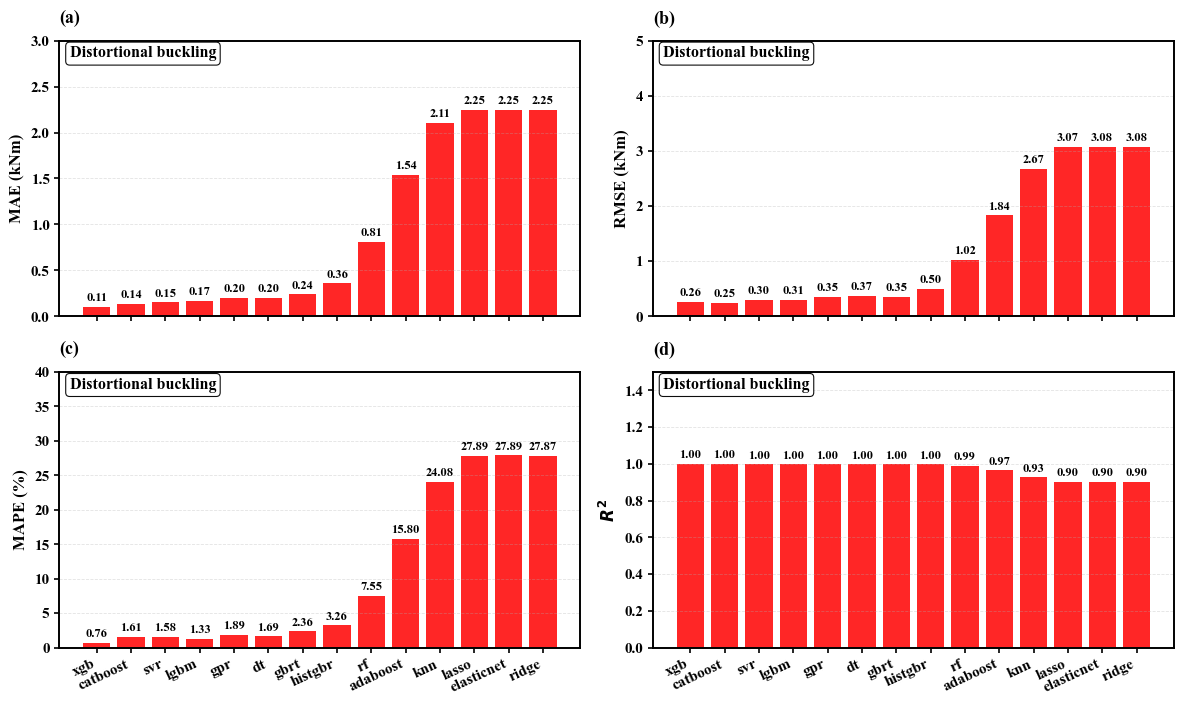

Saved: figures/id_grid_2x2_M_DB.png


In [36]:
# ====== ID performance: add MAPE + 2x2 grid (green=LB, red=DB) ======
import os
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

os.makedirs("figures", exist_ok=True)

mpl.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 12,
    "font.weight": "bold",
    "axes.labelweight": "bold",
    "axes.titleweight": "bold",
    "axes.edgecolor": "black",
    "axes.linewidth": 1.4,
    "xtick.major.width": 1.2,
    "ytick.major.width": 1.2,
})

MODE_LABEL = {"M_LB": "Local buckling", "M_DB": "Distortional buckling"}
BAR_COLOR  = {"M_LB": "green", "M_DB": "red"}  # as requested

def mape_safe(y_true, y_pred, eps=1e-12):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.maximum(np.abs(y_true), eps)
    return float(np.mean(np.abs((y_true - y_pred) / denom)) * 100.0)

def add_mape_to_id_table(target_key):
    """Compute MAPE for each model using stored fitted pipelines + stored ID test split."""
    tab = id_results[target_key]["table"].copy()
    if "Model" in tab.columns and "model" not in tab.columns:
        tab = tab.rename(columns={"Model": "model"})

    fitted = id_results[target_key]["models"]   # dict: model -> pipeline
    splits = id_results[target_key]["splits"]   # dict with X_test/y_test etc.

    X_test = splits["X_test"]
    y_test = splits["y_test"]

    mape_vals = []
    for mk in tab["model"].values:
        pipe = fitted[mk]
        yhat = pipe.predict(X_test)
        mape_vals.append(mape_safe(y_test, yhat))

    tab["MAPE"] = mape_vals
    return tab

def plot_id_grid(tab, target_key, outpath):
    tab = tab.sort_values("MAE").reset_index(drop=True)
    x = np.arange(len(tab))
    labels = tab["model"].values
    c = BAR_COLOR.get(target_key, "gray")

    fig, axs = plt.subplots(2, 2, figsize=(12, 7.2), sharex=True)
    axs = axs.ravel()

    metrics = [
        ("MAE",  "MAE (kNm)",   "(a)", "{:.2f}"),
        ("RMSE", "RMSE (kNm)",  "(b)", "{:.2f}"),
        ("MAPE", "MAPE (%)",    "(c)", "{:.2f}"),
        ("R2",   r"$R^2$",      "(d)", "{:.2f}"),
    ]

    for ax, (m, ylab, panel, fmt) in zip(axs, metrics):
        vals = tab[m].values

        ax.bar(x, vals, color=c, alpha=0.85)
        ax.set_ylabel(ylab)
        ax.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.35)

        # Panel label
        ax.text(0.00, 1.05, panel, transform=ax.transAxes,
                ha="left", va="bottom", fontsize=13, fontweight="bold")

        # Top-left mode label
        ax.text(0.02, 0.98, MODE_LABEL.get(target_key, target_key),
                transform=ax.transAxes, ha="left", va="top",
                fontsize=11.5, fontweight="bold",
                bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="black", lw=0.8, alpha=0.95))

        # Special y-limit for R^2
        if m == "R2":
            ax.set_ylim(0, 1.5)

        # Recompute limits before annotating so labels sit correctly
        ax.relim()
        ax.autoscale_view()

        if m == "R2":
            ax.set_ylim(0, 1.5)
            
        if m == "MAE":
            ax.set_ylim(0, 3.0)

        # Recompute limits before annotating so labels sit correctly
        ax.relim()
        ax.autoscale_view()

        if m == "MAE":
            ax.set_ylim(0, 3.0)
        
        
        if m == "RMSE":
            ax.set_ylim(0, 5)

        # Recompute limits before annotating so labels sit correctly
        ax.relim()
        ax.autoscale_view()

        if m == "RMSE":
            ax.set_ylim(0, 5)
            
        
        if m == "MAPE":
            ax.set_ylim(0, 40)

        # Recompute limits before annotating so labels sit correctly
        ax.relim()
        ax.autoscale_view()

        if m == "MAPE":
            ax.set_ylim(0, 40)
            

        # Annotate bar values
        _annotate_bars(ax, vals, ypad_frac=0.01, fmt=fmt)

        ax.tick_params(axis="both", labelsize=11, width=1.2, colors="black")
        for lab in ax.get_xticklabels() + ax.get_yticklabels():
            lab.set_fontweight("bold")

    # X labels only on bottom row
    for ax in axs[2:]:
        ax.set_xticks(x)
        ax.set_xticklabels(labels, rotation=25, ha="right")

    # fig.suptitle(f"ID performance by model — {MODE_LABEL.get(target_key, target_key)}",
                #  fontsize=14, fontweight="bold", y=1.02)

    fig.tight_layout()
    fig.savefig(outpath, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", outpath)

# ---- Generate the two 2x2 figures ----
for t in targets:  # expects targets = ["M_LB","M_DB"]
    tab = add_mape_to_id_table(t)

    # Also save an updated ID table with MAPE
    os.makedirs("outputs", exist_ok=True)
    tab.to_csv(f"outputs/id_results_{t}_with_MAPE.csv", index=False)

    plot_id_grid(tab, t, f"figures/id_grid_2x2_{t}.png")

In [37]:
# ====== OOD stress tests (with MAPE) ======
import numpy as np
import pandas as pd
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

def mape_safe(y_true, y_pred, eps=1e-12):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.maximum(np.abs(y_true), eps)
    return float(np.mean(np.abs((y_true - y_pred) / denom)) * 100.0)

def regression_metrics(y_true, y_pred):
    return {
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "MAPE": mape_safe(y_true, y_pred),
        "R2": float(r2_score(y_true, y_pred)),
    }

def ood_split_geometry(df, q=0.15):
    if "D" not in df.columns or "t" not in df.columns:
        raise ValueError("Expected columns D and t for geometry OOD split.")
    slender = (df["D"].astype(float) / df["t"].astype(float))
    lo = float(slender.quantile(q))
    hi = float(slender.quantile(1 - q))
    is_test = (slender <= lo) | (slender >= hi)
    meta = {
        "proxy": "D/t",
        "q": float(q),
        "lo": lo,
        "hi": hi,
        "test_frac": float(is_test.mean()),
        "n_test": int(is_test.sum())
    }
    return is_test, meta

def ood_split_group(df, colname):
    if colname not in df.columns:
        raise ValueError(f"Expected column {colname} for OOD split.")
    val, cnt, frac = choose_group_holdout(df[colname])
    is_test = (df[colname] == val)
    meta = {"col": colname, "held_out_value": val, "count": int(cnt), "test_frac": float(frac)}
    return is_test, meta

ood_scenarios = {
    "OOD-Geometry": lambda _df: ood_split_geometry(_df, q=0.15),
    "OOD-Perforation": lambda _df: ood_split_group(_df, "Lsl"),
    "OOD-Material": lambda _df: ood_split_group(_df, "Fy"),
}

ood_rows = []
ood_meta = {}

for scen, splitter in ood_scenarios.items():
    is_test, meta = splitter(df)
    ood_meta[scen] = meta

    X_train = df.loc[~is_test, X_cols].copy()
    X_test  = df.loc[is_test,  X_cols].copy()

    for t in targets:
        y_train = df.loc[~is_test, t].astype(float).copy()
        y_test  = df.loc[is_test,  t].astype(float).copy()

        # Best ID model for this target (lowest MAE)
        tab = id_results[t]["table"].copy()
        if "Model" in tab.columns and "model" not in tab.columns:
            tab = tab.rename(columns={"Model": "model"})
        best_model_name = tab.iloc[0]["model"]

        pipe = id_results[t]["models"][best_model_name]
        pipe.fit(X_train, y_train)
        yhat = pipe.predict(X_test)

        met = regression_metrics(y_test, yhat)
        met.update({
            "Scenario": scen,
            "Model": best_model_name,
            "Target": t,
            "n_test": int(len(y_test))
        })
        ood_rows.append(met)

ood_df = pd.DataFrame(ood_rows)
ood_df

,MAE,RMSE,MAPE,R2,Scenario,Model,Target,n_test
0,13.670148,14.131183,136.153545,-2.194197,OOD-Geometry,xgb,M_LB,144
1,9.176599,9.861263,128.982459,-1.255221,OOD-Geometry,xgb,M_DB,144
2,0.163150,0.210834,1.045067,0.999645,OOD-Perforation,xgb,M_LB,216
3,0.192013,0.274893,1.759111,0.999107,OOD-Perforation,xgb,M_DB,216
4,5.868239,7.092580,45.855074,0.022734,OOD-Material,xgb,M_LB,144
5,4.274711,5.193773,37.955044,0.311835,OOD-Material,xgb,M_DB,144


In [38]:
# ====== OOD stress tests for ALL MODELS (MAE, RMSE, MAPE, R^2) ======
import os, json
import numpy as np
import pandas as pd
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.base import clone

def mape_safe(y_true, y_pred, eps=1e-12):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.maximum(np.abs(y_true), eps)
    return float(np.mean(np.abs((y_true - y_pred) / denom)) * 100.0)

def regression_metrics(y_true, y_pred):
    return {
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "MAPE": mape_safe(y_true, y_pred),
        "R2": float(r2_score(y_true, y_pred)),
    }

def ood_split_geometry(df, q=0.15):
    if "D" not in df.columns or "t" not in df.columns:
        raise ValueError("Expected columns D and t for geometry OOD split.")
    slender = (df["D"].astype(float) / df["t"].astype(float))
    lo = float(slender.quantile(q))
    hi = float(slender.quantile(1 - q))
    is_test = (slender <= lo) | (slender >= hi)
    meta = {"scenario":"OOD-Geometry", "proxy":"D/t", "q":float(q), "lo":lo, "hi":hi,
            "n_test":int(is_test.sum()), "test_frac":float(is_test.mean())}
    return is_test, meta

def ood_split_group(df, colname):
    if colname not in df.columns:
        raise ValueError(f"Expected column {colname} for OOD split.")
    val, cnt, frac = choose_group_holdout(df[colname])
    is_test = (df[colname] == val)
    meta = {"scenario":f"OOD-{colname}", "col":colname, "held_out_value":val,
            "n_test":int(cnt), "test_frac":float(frac)}
    return is_test, meta

ood_scenarios = {
    "OOD-Geometry": lambda _df: ood_split_geometry(_df, q=0.15),
    "OOD-Perforation": lambda _df: ood_split_group(_df, "Lsl"),
    "OOD-Material": lambda _df: ood_split_group(_df, "Fy"),
}

ood_rows = []
ood_meta = {}

for scen, splitter in ood_scenarios.items():
    is_test, meta = splitter(df)
    ood_meta[scen] = meta

    X_train = df.loc[~is_test, X_cols].copy()
    X_test  = df.loc[is_test,  X_cols].copy()

    for t in targets:
        y_train = df.loc[~is_test, t].astype(float).copy()
        y_test  = df.loc[is_test,  t].astype(float).copy()

        # all models available for this target
        tab = id_results[t]["table"].copy()
        if "Model" in tab.columns and "model" not in tab.columns:
            tab = tab.rename(columns={"Model": "model"})

        model_names = tab["model"].tolist()

        for mk in model_names:
            # IMPORTANT: clone before refit so we don't overwrite the stored fitted pipeline
            base_pipe = id_results[t]["models"][mk]
            pipe = clone(base_pipe)

            pipe.fit(X_train, y_train)
            yhat = pipe.predict(X_test)

            met = regression_metrics(y_test, yhat)
            met.update({
                "Scenario": scen,
                "Model": mk,
                "Target": t,
                "n_test": int(len(y_test))
            })
            ood_rows.append(met)

ood_df_all = pd.DataFrame(ood_rows)

# Sort nicely
ood_df_all = ood_df_all.sort_values(["Target", "Scenario", "MAE"]).reset_index(drop=True)
ood_df_all.head(20)

C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000087 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 32
[LightGBM] [Info] Number of data points in the train set: 288, number of used features: 9
[LightGBM] [Info] Start training from score 18.395282
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000077 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 32
[LightGBM] [Info] Number of data points in the train set: 288, number of used features: 9
[LightGBM] [Info] Start training from score 15.229950
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


...

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000101 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 31
[LightGBM] [Info] Number of data points in the train set: 288, number of used features: 9
[LightGBM] [Info] Start training from score 19.118441
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000077 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 31
[LightGBM] [Info] Number of data points in the train set: 288, number of used features: 9
[LightGBM] [Info] Start training from score 15.592974
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

,MAE,RMSE,MAPE,R2,Scenario,Model,Target,n_test
0,2.106458,2.187481,25.111726,0.889028,OOD-Geometry,gpr,M_DB,144
1,3.825528,3.935003,52.808303,0.640901,OOD-Geometry,svr,M_DB,144
2,4.108343,4.615695,51.294384,0.505919,OOD-Geometry,elasticnet,M_DB,144
3,4.108343,4.615757,51.276050,0.505906,OOD-Geometry,lasso,M_DB,144
4,4.108343,4.615024,51.421114,0.506062,OOD-Geometry,ridge,M_DB,144
5,5.514672,6.199110,85.971297,0.108784,OOD-Geometry,catboost,M_DB,144
6,5.939263,6.976500,92.585147,-0.128754,OOD-Geometry,knn,M_DB,144
7,6.377223,7.227179,96.246250,-0.211328,OOD-Geometry,rf,M_DB,144
8,8.065030,9.321349,117.261591,-1.015031,OOD-Geometry,adaboost,M_DB,144
9,9.176599,9.861263,128.982459,-1.255221,OOD-Geometry,xgb,M_DB,144


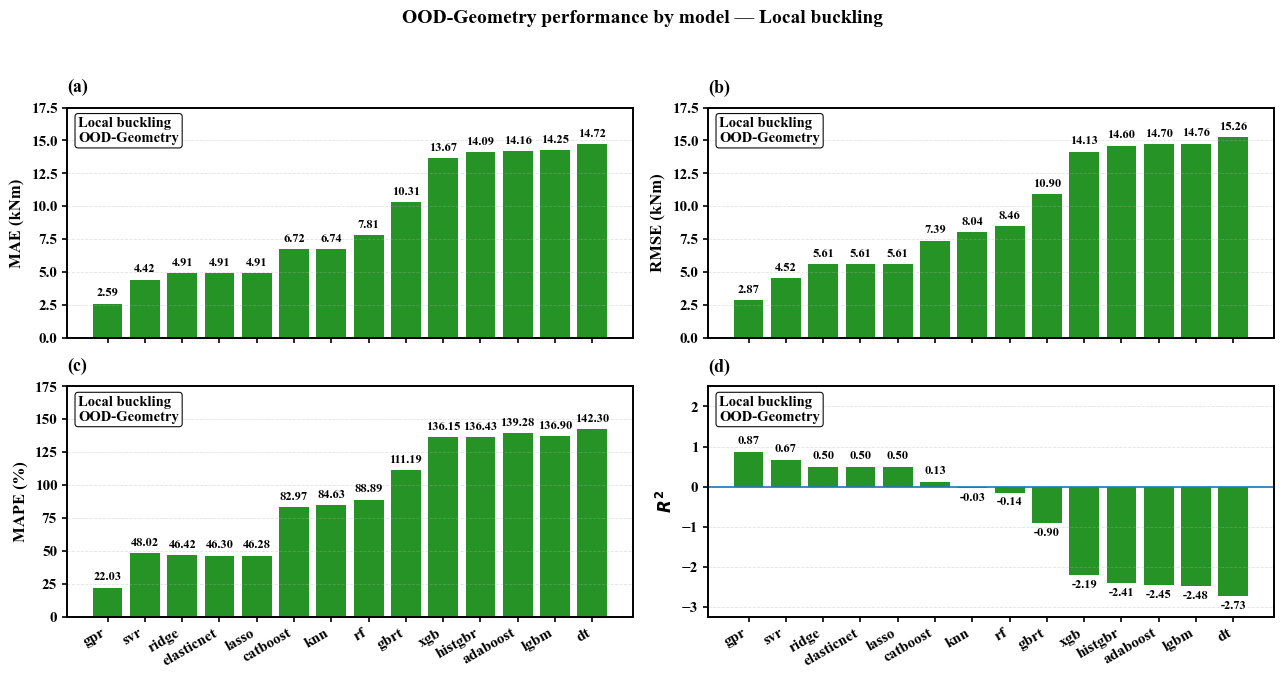

Saved: figures/ood_geometry_grid_2x2_M_LB_FIXED.png


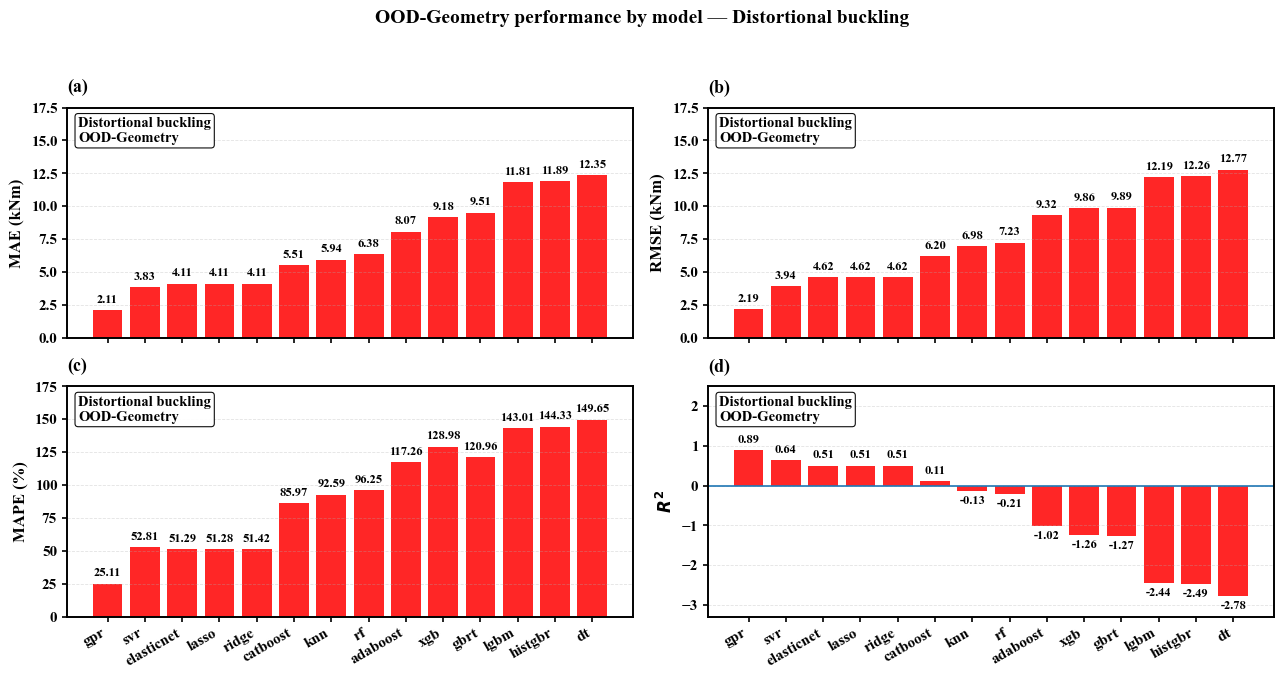

Saved: figures/ood_geometry_grid_2x2_M_DB_FIXED.png


In [43]:
import os
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

os.makedirs("figures", exist_ok=True)

mpl.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 12,
    "font.weight": "bold",
    "axes.labelweight": "bold",
    "axes.titleweight": "bold",
    "axes.edgecolor": "black",
    "axes.linewidth": 1.4,
    "xtick.major.width": 1.2,
    "ytick.major.width": 1.2,
})

MODE_LABEL = {"M_LB": "Local buckling", "M_DB": "Distortional buckling"}
BAR_COLOR  = {"M_LB": "green", "M_DB": "red"}
SCEN = "OOD-Geometry"

def _annotate_bars_signed(ax, values, fmt="{:.2f}", pad_frac=0.02):
    """
    Annotate positive bars above, negative bars below, staying inside axes.
    """
    y0, y1 = ax.get_ylim()
    yr = (y1 - y0) if (y1 - y0) != 0 else 1.0
    pad = pad_frac * yr

    for i, v in enumerate(values):
        if not np.isfinite(v):
            continue
        if v >= 0:
            ax.text(i, v + pad, fmt.format(v),
                    ha="center", va="bottom",
                    fontsize=9, fontweight="bold", clip_on=True)
        else:
            ax.text(i, v - pad, fmt.format(v),
                    ha="center", va="top",
                    fontsize=9, fontweight="bold", clip_on=True)

def plot_ood_grid_for_target_fixed(df_ood, target_key, outpath):
    sub = df_ood[(df_ood["Scenario"] == SCEN) & (df_ood["Target"] == target_key)].copy()
    if sub.empty:
        raise ValueError(f"No rows found for Scenario={SCEN} and Target={target_key}")

    # Consistent ordering: sort by MAE
    sub = sub.sort_values("MAE").reset_index(drop=True)

    x = np.arange(len(sub))
    labels = sub["Model"].astype(str).values
    c = BAR_COLOR.get(target_key, "gray")

    fig, axs = plt.subplots(2, 2, figsize=(13, 7.4), sharex=True)
    axs = axs.ravel()

    metrics = [
        ("MAE",  "MAE (kNm)",   "(a)"),
        ("RMSE", "RMSE (kNm)",  "(b)"),
        ("MAPE", "MAPE (%)",    "(c)"),
        ("R2",   r"$R^2$",      "(d)"),
    ]

    for ax, (m, ylab, panel) in zip(axs, metrics):
        vals = sub[m].values.astype(float)

        ax.bar(x, vals, color=c, alpha=0.85)
        ax.set_ylabel(ylab)
        ax.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.35)

        # Panel label
        ax.text(0.00, 1.05, panel, transform=ax.transAxes,
                ha="left", va="bottom", fontsize=13, fontweight="bold")

        # Top-left mode + scenario label (slightly smaller, less intrusive)
        ax.text(0.02, 0.96, f"{MODE_LABEL.get(target_key, target_key)}\n{SCEN}",
                transform=ax.transAxes, ha="left", va="top",
                fontsize=10.5, fontweight="bold",
                bbox=dict(boxstyle="round,pad=0.22", fc="white", ec="black", lw=0.8, alpha=0.95))

        # Special handling for R^2: allow negatives + zero line
        if m == "R2":
            rmin = float(np.nanmin(vals))
            # show down to slightly below min (but not too tight)
            low = min(-0.1, rmin - 0.15 * abs(rmin) - 0.10)
            ax.set_ylim(low, 2.5)
            ax.axhline(0.0, linewidth=1.2)  # default color, no explicit color spec

        # For other metrics you can still cap if you want (optional):
        if m == "MAE":  ax.set_ylim(0, 17.5)  # etc.
        if m == "RMSE":  ax.set_ylim(0, 17.5)  # etc.
        if m == "MAPE":  ax.set_ylim(0, 175)  # etc.

        # Annotate values (2 dp) with sign-aware placement
        _annotate_bars_signed(ax, vals, fmt="{:.2f}", pad_frac=0.02)

        ax.tick_params(axis="both", labelsize=11, width=1.2, colors="black")
        for lab in ax.get_xticklabels() + ax.get_yticklabels():
            lab.set_fontweight("bold")

    # X labels only on bottom row (give more room)
    for ax in axs[2:]:
        ax.set_xticks(x)
        ax.set_xticklabels(labels, rotation=30, ha="right")

    fig.suptitle(f"{SCEN} performance by model — {MODE_LABEL.get(target_key, target_key)}",
                 fontsize=14, fontweight="bold", y=1.02)

    fig.tight_layout()
    fig.subplots_adjust(bottom=0.20)  # extra space for rotated labels
    fig.savefig(outpath, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", outpath)

# ---- Create the two fixed figures ----
plot_ood_grid_for_target_fixed(ood_df_all, "M_LB", "figures/ood_geometry_grid_2x2_M_LB_FIXED.png")
plot_ood_grid_for_target_fixed(ood_df_all, "M_DB", "figures/ood_geometry_grid_2x2_M_DB_FIXED.png")

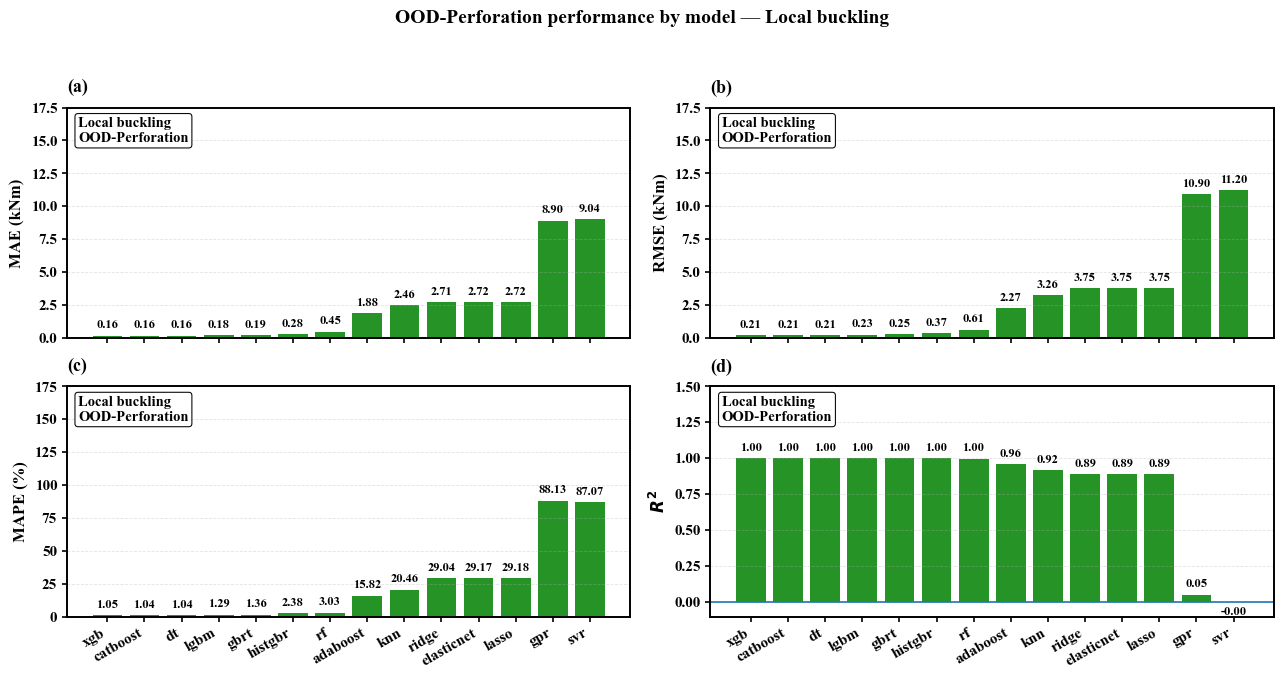

Saved: figures/ood_perforation_grid_2x2_M_LB.png


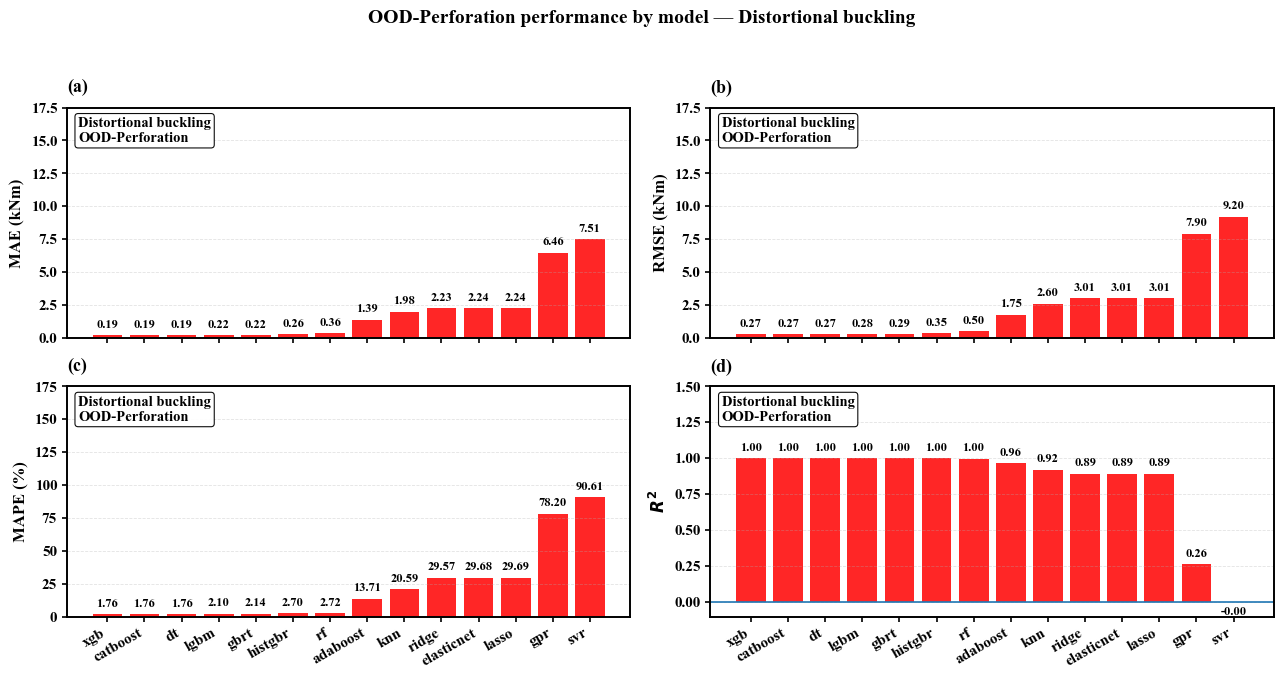

Saved: figures/ood_perforation_grid_2x2_M_DB.png


In [45]:
# ====== OOD-Perforation 2x2 grids (same settings as the FIXED OOD-Geometry plots) ======
import os
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

os.makedirs("figures", exist_ok=True)

mpl.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 12,
    "font.weight": "bold",
    "axes.labelweight": "bold",
    "axes.titleweight": "bold",
    "axes.edgecolor": "black",
    "axes.linewidth": 1.4,
    "xtick.major.width": 1.2,
    "ytick.major.width": 1.2,
})

MODE_LABEL = {"M_LB": "Local buckling", "M_DB": "Distortional buckling"}
BAR_COLOR  = {"M_LB": "green", "M_DB": "red"}
SCEN = "OOD-Perforation"

def _annotate_bars_signed(ax, values, fmt="{:.2f}", pad_frac=0.02):
    y0, y1 = ax.get_ylim()
    yr = (y1 - y0) if (y1 - y0) != 0 else 1.0
    pad = pad_frac * yr
    for i, v in enumerate(values):
        if not np.isfinite(v):
            continue
        if v >= 0:
            ax.text(i, v + pad, fmt.format(v),
                    ha="center", va="bottom",
                    fontsize=9, fontweight="bold", clip_on=True)
        else:
            ax.text(i, v - pad, fmt.format(v),
                    ha="center", va="top",
                    fontsize=9, fontweight="bold", clip_on=True)

def plot_ood_grid_for_target_fixed(df_ood, target_key, outpath):
    sub = df_ood[(df_ood["Scenario"] == SCEN) & (df_ood["Target"] == target_key)].copy()
    if sub.empty:
        raise ValueError(f"No rows found for Scenario={SCEN} and Target={target_key}")

    # order by MAE (consistent ordering across subplots within this scenario/target)
    sub = sub.sort_values("MAE").reset_index(drop=True)

    x = np.arange(len(sub))
    labels = sub["Model"].astype(str).values
    c = BAR_COLOR.get(target_key, "gray")

    fig, axs = plt.subplots(2, 2, figsize=(13, 7.4), sharex=True)
    axs = axs.ravel()

    metrics = [
        ("MAE",  "MAE (kNm)",   "(a)"),
        ("RMSE", "RMSE (kNm)",  "(b)"),
        ("MAPE", "MAPE (%)",    "(c)"),
        ("R2",   r"$R^2$",      "(d)"),
    ]

    for ax, (m, ylab, panel) in zip(axs, metrics):
        vals = sub[m].values.astype(float)

        ax.bar(x, vals, color=c, alpha=0.85)
        ax.set_ylabel(ylab)
        ax.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.35)

        ax.text(0.00, 1.05, panel, transform=ax.transAxes,
                ha="left", va="bottom", fontsize=13, fontweight="bold")

        ax.text(0.02, 0.96, f"{MODE_LABEL.get(target_key, target_key)}\n{SCEN}",
                transform=ax.transAxes, ha="left", va="top",
                fontsize=10.5, fontweight="bold",
                bbox=dict(boxstyle="round,pad=0.22", fc="white", ec="black", lw=0.8, alpha=0.95))

        # R^2: allow negatives if any, and cap top at 1.5
        if m == "R2":
            rmin = float(np.nanmin(vals))
            low = min(-0.1, rmin - 0.15 * abs(rmin) - 0.10)
            ax.set_ylim(low, 1.5)
            ax.axhline(0.0, linewidth=1.2)
            
        if m == "MAE":  ax.set_ylim(0, 17.5)  # etc.
        if m == "RMSE":  ax.set_ylim(0, 17.5)  # etc.
        if m == "MAPE":  ax.set_ylim(0, 175)  # etc.

        _annotate_bars_signed(ax, vals, fmt="{:.2f}", pad_frac=0.02)

        ax.tick_params(axis="both", labelsize=11, width=1.2, colors="black")
        for lab in ax.get_xticklabels() + ax.get_yticklabels():
            lab.set_fontweight("bold")

    for ax in axs[2:]:
        ax.set_xticks(x)
        ax.set_xticklabels(labels, rotation=30, ha="right")

    fig.suptitle(f"{SCEN} performance by model — {MODE_LABEL.get(target_key, target_key)}",
                 fontsize=14, fontweight="bold", y=1.02)

    fig.tight_layout()
    fig.subplots_adjust(bottom=0.20)
    fig.savefig(outpath, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", outpath)

# ---- Generate the two figures (LB and DB) ----
plot_ood_grid_for_target_fixed(ood_df_all, "M_LB", "figures/ood_perforation_grid_2x2_M_LB.png")
plot_ood_grid_for_target_fixed(ood_df_all, "M_DB", "figures/ood_perforation_grid_2x2_M_DB.png")

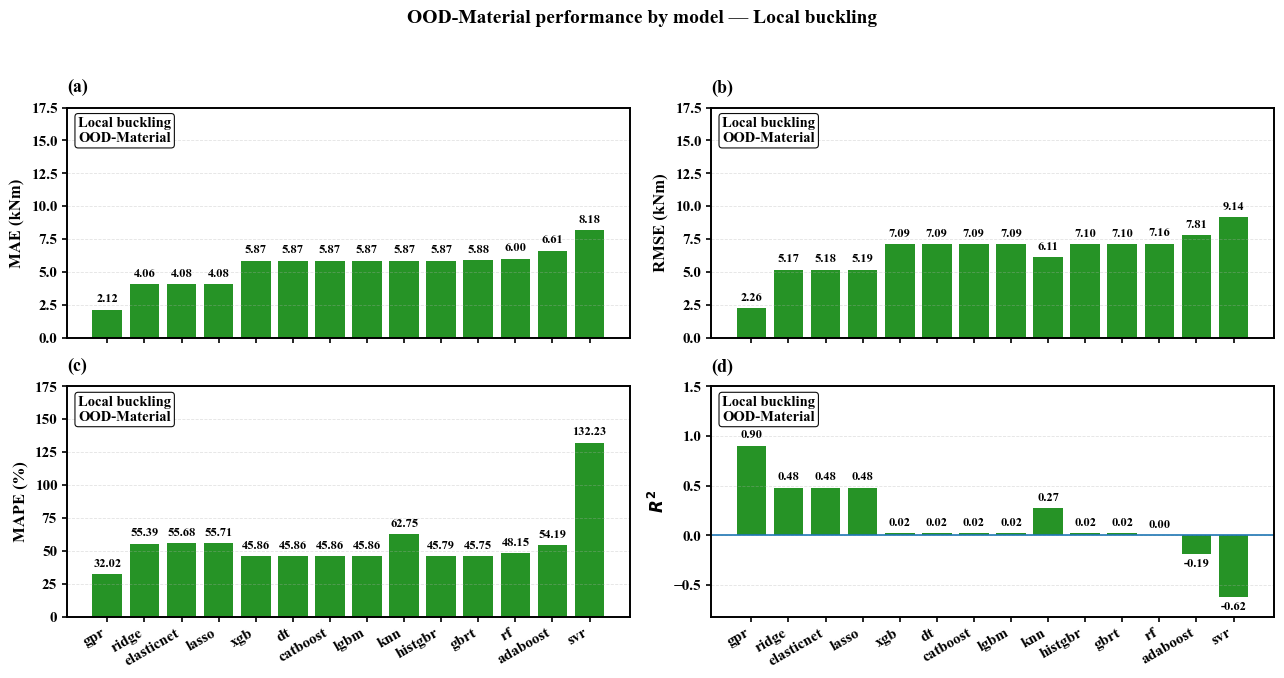

Saved: figures/ood_material_grid_2x2_M_LB.png


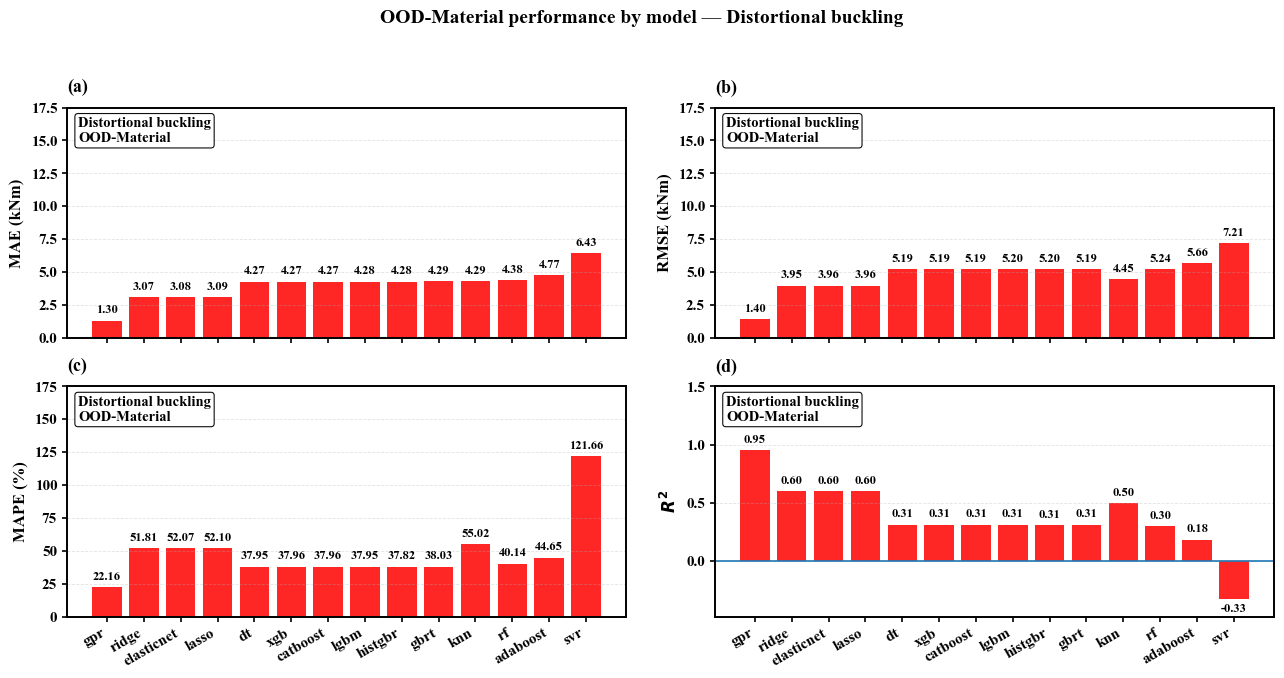

Saved: figures/ood_material_grid_2x2_M_DB.png


In [47]:
# ====== OOD-Material 2x2 grids (same settings as the FIXED OOD-Geometry plots) ======
import os
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

os.makedirs("figures", exist_ok=True)

mpl.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 12,
    "font.weight": "bold",
    "axes.labelweight": "bold",
    "axes.titleweight": "bold",
    "axes.edgecolor": "black",
    "axes.linewidth": 1.4,
    "xtick.major.width": 1.2,
    "ytick.major.width": 1.2,
})

MODE_LABEL = {"M_LB": "Local buckling", "M_DB": "Distortional buckling"}
BAR_COLOR  = {"M_LB": "green", "M_DB": "red"}
SCEN = "OOD-Material"

def _annotate_bars_signed(ax, values, fmt="{:.2f}", pad_frac=0.02):
    y0, y1 = ax.get_ylim()
    yr = (y1 - y0) if (y1 - y0) != 0 else 1.0
    pad = pad_frac * yr
    for i, v in enumerate(values):
        if not np.isfinite(v):
            continue
        if v >= 0:
            ax.text(i, v + pad, fmt.format(v),
                    ha="center", va="bottom",
                    fontsize=9, fontweight="bold", clip_on=True)
        else:
            ax.text(i, v - pad, fmt.format(v),
                    ha="center", va="top",
                    fontsize=9, fontweight="bold", clip_on=True)

def plot_ood_grid_for_target_fixed(df_ood, target_key, outpath):
    sub = df_ood[(df_ood["Scenario"] == SCEN) & (df_ood["Target"] == target_key)].copy()
    if sub.empty:
        raise ValueError(f"No rows found for Scenario={SCEN} and Target={target_key}")

    sub = sub.sort_values("MAE").reset_index(drop=True)
    x = np.arange(len(sub))
    labels = sub["Model"].astype(str).values
    c = BAR_COLOR.get(target_key, "gray")

    fig, axs = plt.subplots(2, 2, figsize=(13, 7.4), sharex=True)
    axs = axs.ravel()

    metrics = [
        ("MAE",  "MAE (kNm)",   "(a)"),
        ("RMSE", "RMSE (kNm)",  "(b)"),
        ("MAPE", "MAPE (%)",    "(c)"),
        ("R2",   r"$R^2$",      "(d)"),
    ]

    for ax, (m, ylab, panel) in zip(axs, metrics):
        vals = sub[m].values.astype(float)

        ax.bar(x, vals, color=c, alpha=0.85)
        ax.set_ylabel(ylab)
        ax.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.35)

        ax.text(0.00, 1.05, panel, transform=ax.transAxes,
                ha="left", va="bottom", fontsize=13, fontweight="bold")

        ax.text(0.02, 0.96, f"{MODE_LABEL.get(target_key, target_key)}\n{SCEN}",
                transform=ax.transAxes, ha="left", va="top",
                fontsize=10.5, fontweight="bold",
                bbox=dict(boxstyle="round,pad=0.22", fc="white", ec="black", lw=0.8, alpha=0.95))

        if m == "R2":
            rmin = float(np.nanmin(vals))
            low = min(-0.1, rmin - 0.15 * abs(rmin) - 0.10)
            ax.set_ylim(low, 1.5)
            ax.axhline(0.0, linewidth=1.2)
        if m == "MAE":  ax.set_ylim(0, 17.5)  # etc.
        if m == "RMSE":  ax.set_ylim(0, 17.5)  # etc.
        if m == "MAPE":  ax.set_ylim(0, 175)  # etc.
        _annotate_bars_signed(ax, vals, fmt="{:.2f}", pad_frac=0.02)

        ax.tick_params(axis="both", labelsize=11, width=1.2, colors="black")
        for lab in ax.get_xticklabels() + ax.get_yticklabels():
            lab.set_fontweight("bold")

    for ax in axs[2:]:
        ax.set_xticks(x)
        ax.set_xticklabels(labels, rotation=30, ha="right")

    fig.suptitle(f"{SCEN} performance by model — {MODE_LABEL.get(target_key, target_key)}",
                 fontsize=14, fontweight="bold", y=1.02)

    fig.tight_layout()
    fig.subplots_adjust(bottom=0.20)
    fig.savefig(outpath, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", outpath)

# ---- Generate the two figures (LB and DB) ----
plot_ood_grid_for_target_fixed(ood_df_all, "M_LB", "figures/ood_material_grid_2x2_M_LB.png")
plot_ood_grid_for_target_fixed(ood_df_all, "M_DB", "figures/ood_material_grid_2x2_M_DB.png")

C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000088 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 32
[LightGBM] [Info] Number of data points in the train set: 258, number of used features: 9
[LightGBM] [Info] Start training from score 16.564922
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


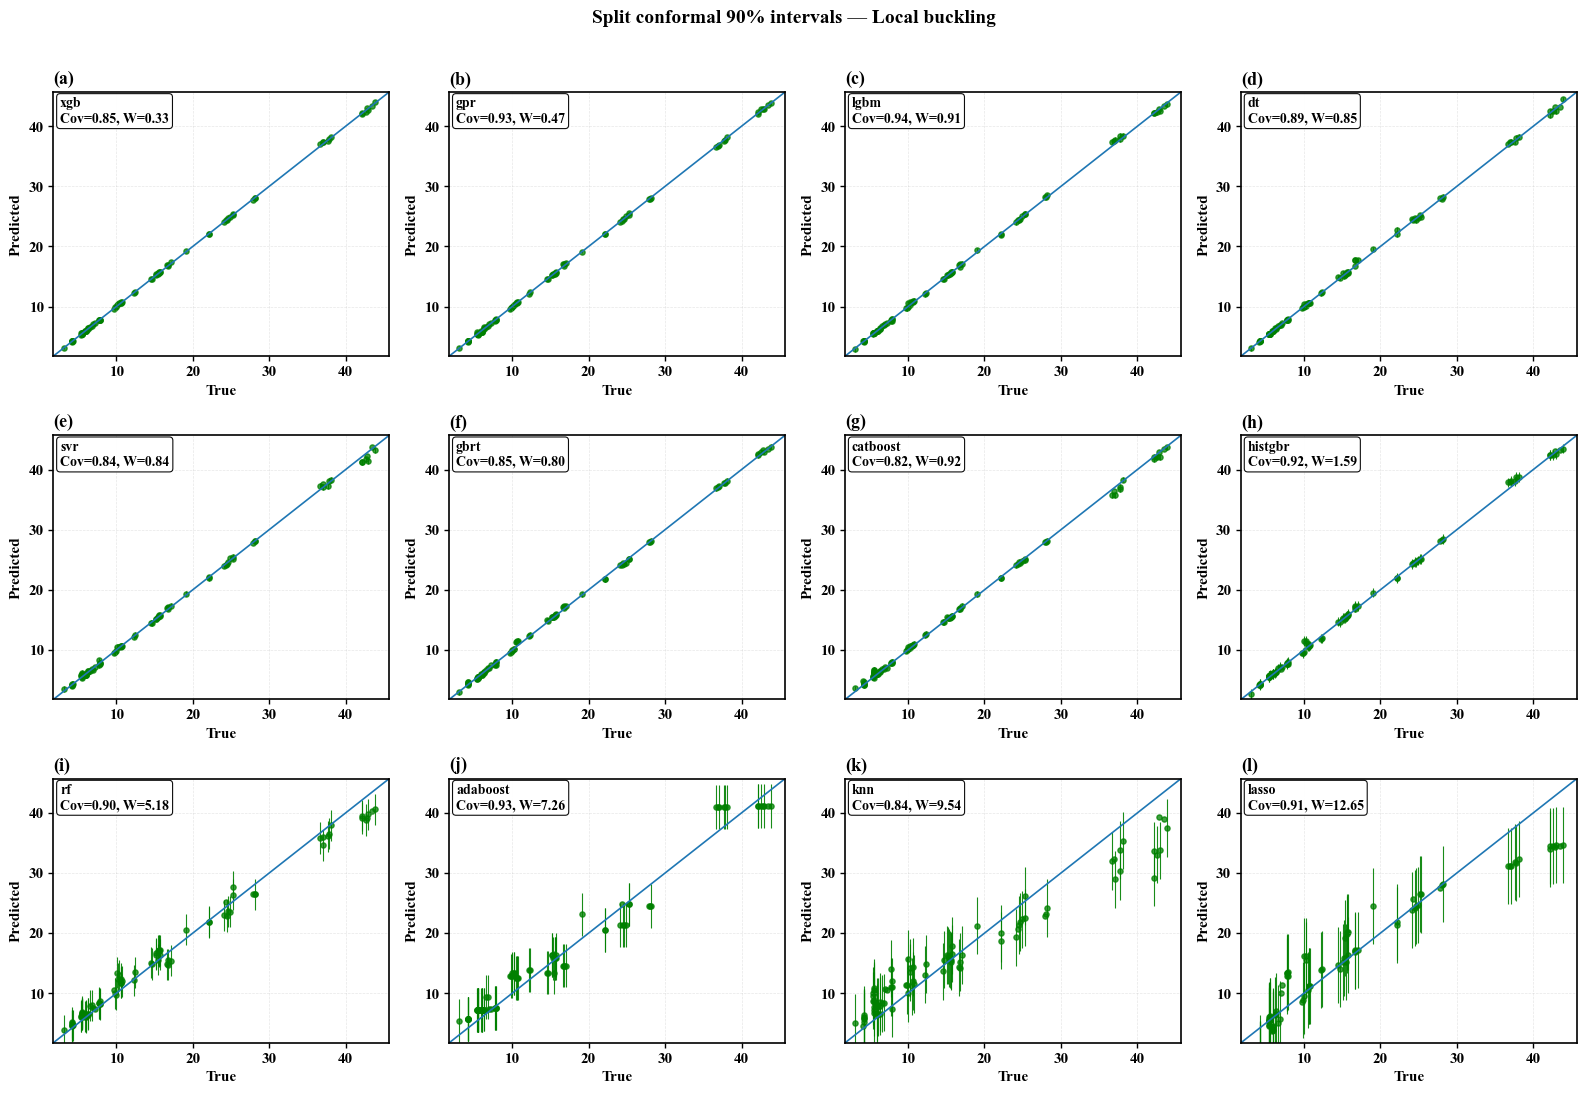

Saved: figures/conformal_grid_M_LB.png


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000076 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 32
[LightGBM] [Info] Number of data points in the train set: 258, number of used features: 9
[LightGBM] [Info] Start training from score 13.726242
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

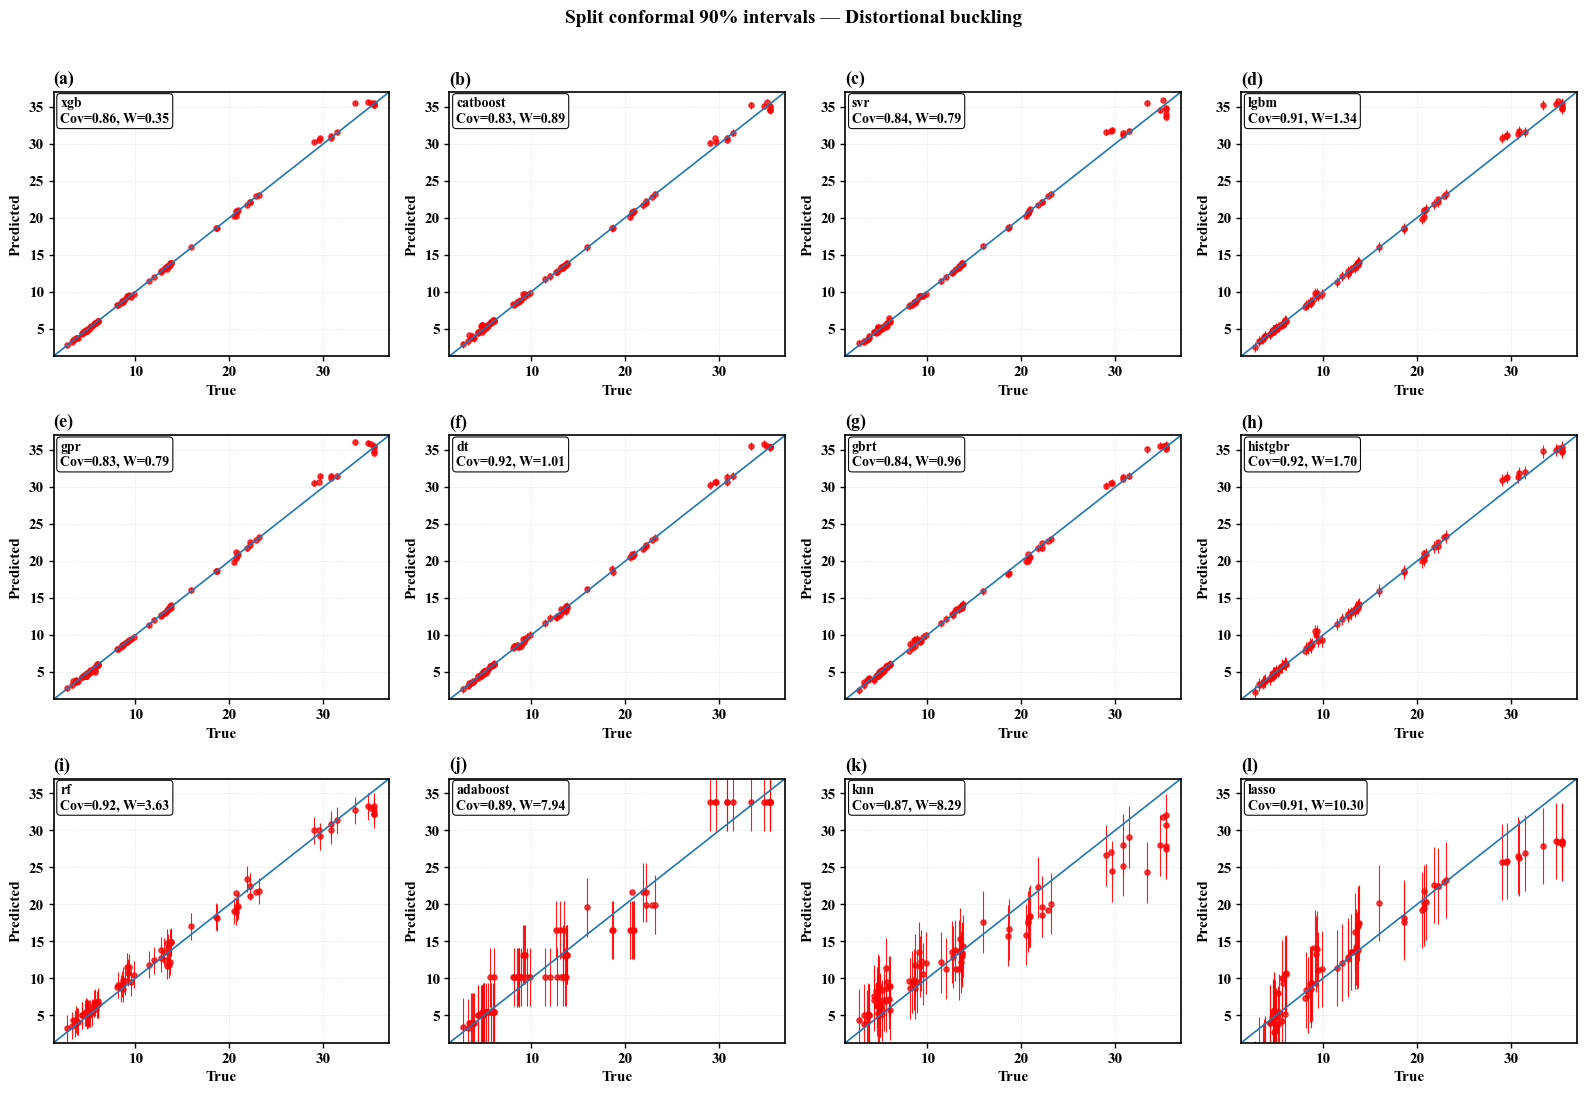

Saved: figures/conformal_grid_M_DB.png


,Target,Model,alpha,calib_size,coverage,avg_interval_width,q_residual,n_test
17,M_DB,dt,0.1,0.25,0.919540,1.011069,0.505534,87
19,M_DB,histgbr,0.1,0.25,0.919540,1.696652,0.848326,87
20,M_DB,rf,0.1,0.25,0.919540,3.627581,1.813791,87
15,M_DB,lgbm,0.1,0.25,0.908046,1.335796,0.667898,87
23,M_DB,lasso,0.1,0.25,0.908046,10.296394,5.148197,87
21,M_DB,adaboost,0.1,0.25,0.885057,7.936940,3.968470,87
22,M_DB,knn,0.1,0.25,0.873563,8.293316,4.146658,87
12,M_DB,xgb,0.1,0.25,0.862069,0.352954,0.176477,87
14,M_DB,svr,0.1,0.25,0.839080,0.793583,0.396792,87
18,M_DB,gbrt,0.1,0.25,0.839080,0.957778,0.478889,87


In [49]:
# ====== Conformal prediction intervals (ALL MODELS) + GRID PLOTS
# Titles as (a),(b),(c)... and color: green=Local (M_LB), red=Distortional (M_DB)
import os
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from sklearn.base import clone

os.makedirs("figures", exist_ok=True)
os.makedirs("outputs", exist_ok=True)

mpl.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 11,
    "font.weight": "bold",
    "axes.labelweight": "bold",
    "axes.titleweight": "bold",
    "axes.edgecolor": "black",
    "axes.linewidth": 1.2,
    "xtick.major.width": 1.0,
    "ytick.major.width": 1.0,
})

alpha = 0.10
calib_size = 0.25
MAX_PANELS = 12      # set to len(models) if you want ALL
N_VLINES = 70

MODE_LABEL = {"M_LB": "Local buckling", "M_DB": "Distortional buckling"}
MODE_COLOR = {"M_LB": "green", "M_DB": "red"}

def panel_label(i):
    # (a), (b), (c) ... up to (z)
    letters = "abcdefghijklmnopqrstuvwxyz"
    if i < len(letters):
        return f"({letters[i]})"
    return f"({i+1})"

def conformal_for_model(pipe, X_train, y_train, X_test, y_test, alpha, calib_size, random_state):
    p = clone(pipe)  # avoid overwriting stored pipeline
    pred, lo, hi, q = split_conformal_intervals(
        p, X_train, y_train, X_test,
        alpha=alpha, calib_size=calib_size, random_state=random_state
    )
    coverage = float(np.mean((y_test.values >= lo) & (y_test.values <= hi)))
    avg_width = float(np.mean(hi - lo))
    return pred, lo, hi, q, coverage, avg_width

conformal_rows = []

for t in targets:
    tab = id_results[t]["table"].copy()
    if "Model" in tab.columns and "model" not in tab.columns:
        tab = tab.rename(columns={"Model": "model"})

    splits = id_results[t]["splits"]
    X_train = splits["X_train"]
    X_test  = splits["X_test"]
    y_train = splits["y_train"]
    y_test  = splits["y_test"]

    # order by ID MAE
    models_ordered = tab["model"].tolist()
    models_to_plot = models_ordered[:min(MAX_PANELS, len(models_ordered))]

    n = len(models_to_plot)
    ncols = 4
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.0*ncols, 3.6*nrows))
    axes = np.array(axes).reshape(-1)

    # common limits per target
    y_min = float(min(y_test.min(), y_train.min()))
    y_max = float(max(y_test.max(), y_train.max()))
    pad = 0.03 * (y_max - y_min if y_max > y_min else 1.0)
    lims = (y_min - pad, y_max + pad)

    col = MODE_COLOR.get(t, "black")

    for i, mk in enumerate(models_to_plot):
        ax = axes[i]
        pipe = id_results[t]["models"][mk]

        pred, lo, hi, q, cov, w = conformal_for_model(
            pipe, X_train, y_train, X_test, y_test,
            alpha=alpha, calib_size=calib_size, random_state=RANDOM_STATE
        )

        conformal_rows.append({
            "Target": t,
            "Model": mk,
            "alpha": float(alpha),
            "calib_size": float(calib_size),
            "coverage": float(cov),
            "avg_interval_width": float(w),
            "q_residual": float(q),
            "n_test": int(len(y_test))
        })

        # colored scatter + intervals
        ax.scatter(y_test.values, pred, s=14, alpha=0.75, color=col)
        k = min(N_VLINES, len(y_test))
        idx = np.random.RandomState(RANDOM_STATE).choice(len(y_test), size=k, replace=False)
        ax.vlines(y_test.values[idx], lo[idx], hi[idx], linewidth=0.8, alpha=0.9, color=col)

        # 1:1 line (default color, not forced)
        ax.plot(lims, lims, linewidth=1.2)

        ax.set_xlim(lims)
        ax.set_ylim(lims)

        # Title as (a), (b), ... only
        ax.set_title(panel_label(i), fontsize=13, fontweight="bold", loc="left")

        # Put model name + stats inside top-left box
        ax.text(
            0.02, 0.98,
            f"{mk}\nCov={cov:.2f}, W={w:.2f}",
            transform=ax.transAxes,
            ha="left", va="top",
            fontsize=10, fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="black", lw=0.8, alpha=0.95)
        )

        ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.30)

        # axis labels
        ax.set_xlabel("True", fontsize=11, fontweight="bold")
        ax.set_ylabel("Predicted", fontsize=11, fontweight="bold")

    for j in range(n, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(f"Split conformal 90% intervals — {MODE_LABEL.get(t, t)}",
                 fontsize=14, fontweight="bold", y=1.01)
    fig.tight_layout()

    out_fig = f"figures/conformal_grid_{t}.png"
    fig.savefig(out_fig, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", out_fig)

conformal_df_all = pd.DataFrame(conformal_rows).sort_values(["Target", "coverage"], ascending=[True, False])
conformal_df_all.to_csv("outputs/conformal_summary_all_models.csv", index=False)
conformal_df_all.head(20)

In [50]:
# ====== Robustness across seeds: ALL models ======
import os
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

os.makedirs("outputs", exist_ok=True)
os.makedirs("figures", exist_ok=True)

seeds = list(range(1, 31))  # 30 repeats

MODE_LABEL = {"M_LB": "Local buckling", "M_DB": "Distortional buckling"}
MODE_COLOR = {"M_LB": "green", "M_DB": "red"}

def mape_safe(y_true, y_pred, eps=1e-12):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.maximum(np.abs(y_true), eps)
    return float(np.mean(np.abs((y_true - y_pred) / denom)) * 100.0)

def regression_metrics(y_true, y_pred):
    return {
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "MAPE": float(mape_safe(y_true, y_pred)),
        "R2": float(r2_score(y_true, y_pred)),
    }

robust_rows = []

for t in targets:
    tab = id_results[t]["table"].copy()
    if "Model" in tab.columns and "model" not in tab.columns:
        tab = tab.rename(columns={"Model": "model"})
    model_names = tab["model"].tolist()

    splits = id_results[t]["splits"]
    X_train = splits["X_train"]
    X_test  = splits["X_test"]
    y_train = splits["y_train"]
    y_test  = splits["y_test"]

    for mk in model_names:
        base_pipe = id_results[t]["models"][mk]

        for sd in seeds:
            # clone to preserve original + set seed when possible
            pipe = clone(base_pipe)

            # try to set random_state on the estimator if it exists
            try:
                est = pipe.named_steps.get("model", None)
                if est is not None and hasattr(est, "random_state"):
                    est.set_params(random_state=sd)
            except Exception:
                pass

            # fit/predict on the SAME fixed ID split
            pipe.fit(X_train, y_train)
            pred = pipe.predict(X_test)
            met = regression_metrics(y_test, pred)

            robust_rows.append({
                "Target": t,
                "Model": mk,
                "seed": int(sd),
                **met
            })

robust_df = pd.DataFrame(robust_rows)
robust_df.to_csv("outputs/robustness_seeds_all_models.csv", index=False)
print("Saved: outputs/robustness_seeds_all_models.csv")
robust_df.head()

C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000119 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 32
[LightGBM] [Info] Number of data points in the train set: 345, number of used features: 9
[LightGBM] [Info] Start training from score 16.934572
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

...

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000095 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 32
[LightGBM] [Info] Number of data points in the train set: 345, number of used features: 9
[LightGBM] [Info] Start training from score 14.012819
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Saved: outputs/robustness_seeds_all_models.csv


,Target,Model,seed,MAE,RMSE,MAPE,R2
0,M_LB,xgb,1,0.081550,0.121768,0.671791,0.999900
1,M_LB,xgb,2,0.076079,0.109507,0.663486,0.999919
2,M_LB,xgb,3,0.059939,0.086956,0.503895,0.999949
3,M_LB,xgb,4,0.071804,0.104059,0.611397,0.999927
4,M_LB,xgb,5,0.076547,0.105717,0.657578,0.999924


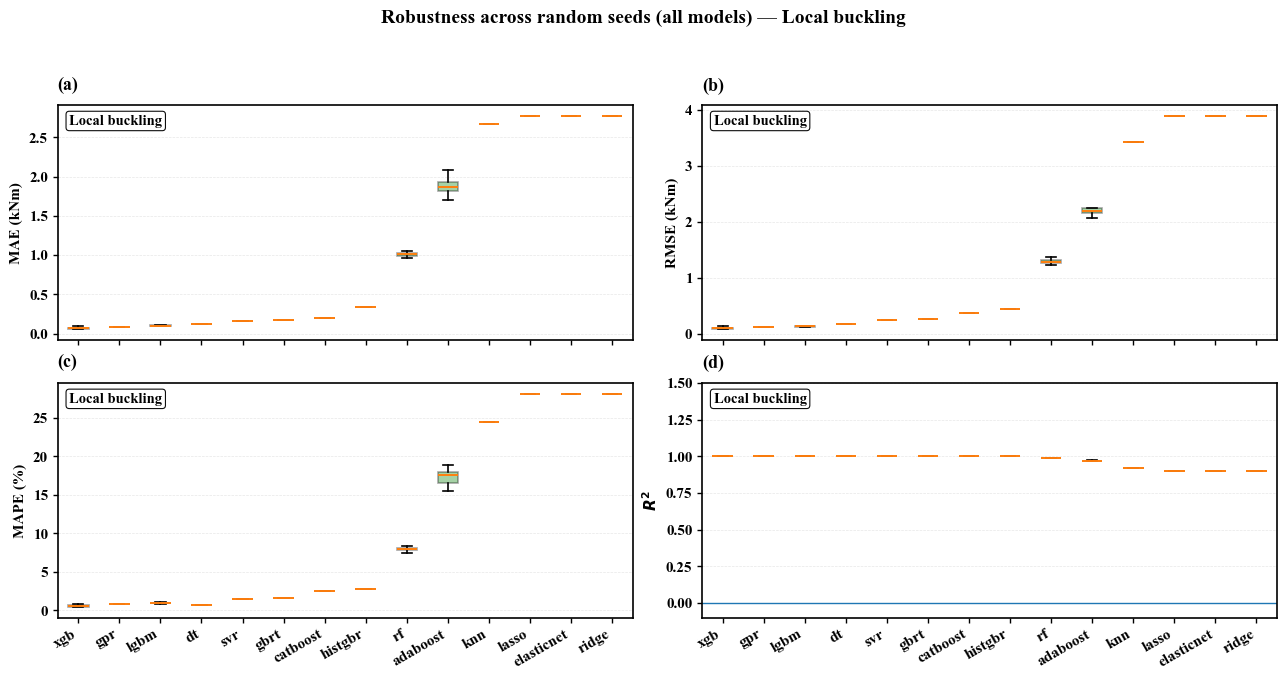

Saved: figures/robustness_grid_all_models_M_LB.png


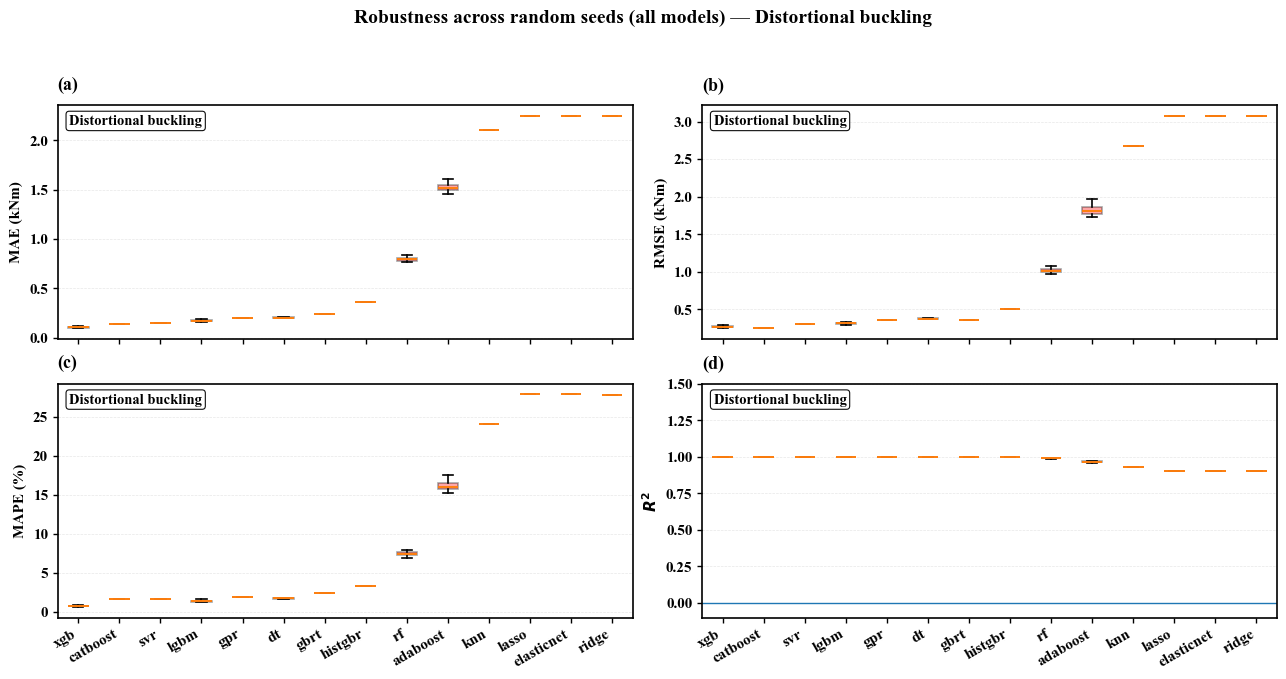

Saved: figures/robustness_grid_all_models_M_DB.png


In [51]:
# ====== Robustness plots: 2x2 grids (boxplots across seeds for all models) ======
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 11,
    "font.weight": "bold",
    "axes.labelweight": "bold",
    "axes.titleweight": "bold",
    "axes.edgecolor": "black",
    "axes.linewidth": 1.2,
    "xtick.major.width": 1.0,
    "ytick.major.width": 1.0,
})

def panel_label(i):
    return f"({chr(ord('a') + i)})"

def plot_robustness_grid(target_key, df_rob, outpath):
    sub = df_rob[df_rob["Target"] == target_key].copy()
    if sub.empty:
        raise ValueError(f"No robustness rows for target={target_key}")

    # model order: by median MAE (best first)
    order = (
        sub.groupby("Model")["MAE"]
        .median()
        .sort_values()
        .index.tolist()
    )

    metrics = [
        ("MAE",  "MAE (kNm)"),
        ("RMSE", "RMSE (kNm)"),
        ("MAPE", "MAPE (%)"),
        ("R2",   r"$R^2$"),
    ]

    fig, axs = plt.subplots(2, 2, figsize=(13, 7.6), sharex=True)
    axs = axs.ravel()

    col = MODE_COLOR.get(target_key, "black")

    for i, (m, ylab) in enumerate(metrics):
        ax = axs[i]
        data = [sub.loc[sub["Model"] == mk, m].values for mk in order]

        bp = ax.boxplot(
            data,
            patch_artist=True,
            showfliers=False,
            medianprops=dict(linewidth=1.4),
            whiskerprops=dict(linewidth=1.2),
            capprops=dict(linewidth=1.2),
        )

        # color boxes (green/red)
        for box in bp["boxes"]:
            box.set_facecolor(col)
            box.set_alpha(0.35)
            box.set_linewidth(1.2)

        ax.set_ylabel(ylab)
        ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.30)

        # panel label
        ax.text(0.00, 1.05, panel_label(i), transform=ax.transAxes,
                ha="left", va="bottom", fontsize=13, fontweight="bold")

        # top-left mode label
        ax.text(0.02, 0.96, MODE_LABEL.get(target_key, target_key),
                transform=ax.transAxes, ha="left", va="top",
                fontsize=10.5, fontweight="bold",
                bbox=dict(boxstyle="round,pad=0.22", fc="white", ec="black", lw=0.8, alpha=0.95))

        # R^2: allow negatives but cap top at 1.5 (like before)
        if m == "R2":
            vmin = float(np.nanmin(sub[m].values))
            low = min(-0.1, vmin - 0.15 * abs(vmin) - 0.10)
            ax.set_ylim(low, 1.5)
            ax.axhline(0.0, linewidth=1.0)

    # x tick labels on bottom row only
    for ax in axs[2:]:
        ax.set_xticks(range(1, len(order) + 1))
        ax.set_xticklabels(order, rotation=30, ha="right")

    fig.suptitle(f"Robustness across random seeds (all models) — {MODE_LABEL.get(target_key, target_key)}",
                 fontsize=14, fontweight="bold", y=1.02)

    fig.tight_layout()
    fig.subplots_adjust(bottom=0.22)
    fig.savefig(outpath, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", outpath)

plot_robustness_grid("M_LB", robust_df, "figures/robustness_grid_all_models_M_LB.png")
plot_robustness_grid("M_DB", robust_df, "figures/robustness_grid_all_models_M_DB.png")

In [52]:
# ====== Robustness summary TABLE for all models (across seeds) ======
import os
import numpy as np
import pandas as pd

os.makedirs("outputs", exist_ok=True)

# expects: robust_df already exists (from robustness_seeds_all_models.csv)
# If not in memory, uncomment:
# robust_df = pd.read_csv("outputs/robustness_seeds_all_models.csv")

metrics = ["MAE", "RMSE", "MAPE", "R2"]

def summarize_group(g):
    out = {}
    for m in metrics:
        x = g[m].astype(float).values
        out[f"{m}_mean"] = float(np.mean(x))
        out[f"{m}_std"]  = float(np.std(x, ddof=1)) if len(x) > 1 else 0.0
        out[f"{m}_median"] = float(np.median(x))
        out[f"{m}_p25"] = float(np.percentile(x, 25))
        out[f"{m}_p75"] = float(np.percentile(x, 75))
        out[f"{m}_iqr"] = out[f"{m}_p75"] - out[f"{m}_p25"]
        out[f"{m}_min"] = float(np.min(x))
        out[f"{m}_max"] = float(np.max(x))
    out["n_seeds"] = int(g["seed"].nunique())
    return pd.Series(out)

summary = (
    robust_df
    .groupby(["Target", "Model"], as_index=False)
    .apply(summarize_group)
    .reset_index(drop=True)
)

# Sort by MAE_mean (best first) within each target
summary = summary.sort_values(["Target", "MAE_mean"]).reset_index(drop=True)

out_csv = "outputs/robustness_summary_all_models.csv"
out_xlsx = "outputs/robustness_summary_all_models.xlsx"
summary.to_csv(out_csv, index=False)
summary.to_excel(out_xlsx, index=False)

print("Saved:", out_csv)
print("Saved:", out_xlsx)
summary.head(20)

C:\Users\DELL\AppData\Local\Temp\ipykernel_15564\3407256508.py:32: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(summarize_group)


Saved: outputs/robustness_summary_all_models.csv
Saved: outputs/robustness_summary_all_models.xlsx


,Target,Model,MAE_mean,MAE_std,MAE_median,MAE_p25,MAE_p75,MAE_iqr,MAE_min,MAE_max,...,MAPE_max,R2_mean,R2_std,R2_median,R2_p25,R2_p75,R2_iqr,R2_min,R2_max,n_seeds
0,M_DB,xgb,0.105124,5.425334e-03,0.105060,0.101576,0.107301,5.725463e-03,0.095804,0.119645,...,0.862668,0.999281,7.002999e-05,0.999274,0.999246,0.999318,0.000072,0.999145,0.999447,30.0
1,M_DB,catboost,0.135107,0.000000e+00,0.135107,0.135107,0.135107,0.000000e+00,0.135107,0.135107,...,1.614706,0.999389,1.129203e-16,0.999389,0.999389,0.999389,0.000000,0.999389,0.999389,30.0
2,M_DB,svr,0.154253,0.000000e+00,0.154253,0.154253,0.154253,0.000000e+00,0.154253,0.154253,...,1.575830,0.999105,2.258405e-16,0.999105,0.999105,0.999105,0.000000,0.999105,0.999105,30.0
3,M_DB,lgbm,0.175539,6.711224e-03,0.174358,0.172131,0.180209,8.078525e-03,0.162620,0.189678,...,1.583660,0.999013,4.530555e-05,0.999013,0.998991,0.999044,0.000053,0.998912,0.999120,30.0
4,M_DB,gpr,0.200080,5.646013e-17,0.200080,0.200080,0.200080,0.000000e+00,0.200080,0.200080,...,1.889463,0.998740,1.129203e-16,0.998740,0.998740,0.998740,0.000000,0.998740,0.998740,30.0
5,M_DB,dt,0.202870,3.536480e-03,0.202025,0.200389,0.206270,5.881029e-03,0.196336,0.207289,...,1.748169,0.998573,1.068148e-05,0.998577,0.998563,0.998580,0.000017,0.998561,0.998592,30.0
6,M_DB,gbrt,0.242415,2.873833e-16,0.242415,0.242415,0.242415,3.608225e-16,0.242415,0.242415,...,2.360770,0.998754,1.129203e-16,0.998754,0.998754,0.998754,0.000000,0.998754,0.998754,30.0
7,M_DB,histgbr,0.361029,1.129203e-16,0.361029,0.361029,0.361029,0.000000e+00,0.361029,0.361029,...,3.256189,0.997474,1.129203e-16,0.997474,0.997474,0.997474,0.000000,0.997474,0.997474,30.0
8,M_DB,rf,0.797879,2.441757e-02,0.794132,0.779776,0.807661,2.788534e-02,0.762142,0.862402,...,7.915326,0.989463,6.630124e-04,0.989621,0.989074,0.989841,0.000766,0.987378,0.990500,30.0
9,M_DB,adaboost,1.522767,4.598381e-02,1.514498,1.497308,1.546475,4.916710e-02,1.451574,1.649969,...,17.549031,0.966040,3.051660e-03,0.966734,0.964672,0.968181,0.003509,0.955284,0.969778,30.0


In [53]:
# ====== MAE inflation factors (ALL models, ALL scenarios) ======
import os
import numpy as np
import pandas as pd

os.makedirs("outputs", exist_ok=True)

# --- Load from memory if available; otherwise load from CSVs ---
# expects: id_results (dict) and ood_df_all (DataFrame) in memory
# If not, uncomment these:
# ood_df_all = pd.read_csv("outputs/ood_results_all_models.csv")
# id_lb = pd.read_csv("outputs/id_results_M_LB.csv")
# id_db = pd.read_csv("outputs/id_results_M_DB.csv")

def get_id_mae_table_from_id_results():
    rows = []
    for t in targets:
        tab = id_results[t]["table"].copy()
        if "Model" in tab.columns and "model" not in tab.columns:
            tab = tab.rename(columns={"Model": "model"})
        for _, r in tab.iterrows():
            rows.append({"Target": t, "Model": r["model"], "MAE_ID": float(r["MAE"])})
    return pd.DataFrame(rows)

id_mae = get_id_mae_table_from_id_results()

ood_mae = ood_df_all[["Target", "Model", "Scenario", "MAE"]].copy()
ood_mae = ood_mae.rename(columns={"MAE": "MAE_OOD"})

# Merge + compute inflation
infl = ood_mae.merge(id_mae, on=["Target", "Model"], how="left")

# protect against divide by zero
eps = 1e-12
infl["Inflation_MAE"] = infl["MAE_OOD"] / np.maximum(infl["MAE_ID"], eps)

# Sort nicely
infl = infl.sort_values(["Target", "Scenario", "Inflation_MAE"], ascending=[True, True, False]).reset_index(drop=True)

out_csv = "outputs/mae_inflation_all_models.csv"
infl.to_csv(out_csv, index=False)
print("Saved:", out_csv)

# Wide/pivot format (one row per model, columns = scenarios)
pivot = infl.pivot_table(
    index=["Target", "Model"],
    columns="Scenario",
    values="Inflation_MAE",
    aggfunc="first"
).reset_index()

out_pivot = "outputs/mae_inflation_all_models_pivot.csv"
pivot.to_csv(out_pivot, index=False)
print("Saved:", out_pivot)

infl.head(20)

Saved: outputs/mae_inflation_all_models.csv
Saved: outputs/mae_inflation_all_models_pivot.csv


,Target,Model,Scenario,MAE_OOD,MAE_ID,Inflation_MAE
0,M_DB,xgb,OOD-Geometry,9.176599,0.106837,85.893697
1,M_DB,lgbm,OOD-Geometry,11.812874,0.169208,69.812841
2,M_DB,dt,OOD-Geometry,12.354313,0.200567,61.596885
3,M_DB,catboost,OOD-Geometry,5.514672,0.135107,40.817170
4,M_DB,gbrt,OOD-Geometry,9.514785,0.242415,39.250008
5,M_DB,histgbr,OOD-Geometry,11.886407,0.361029,32.923716
6,M_DB,svr,OOD-Geometry,3.825528,0.154253,24.800377
7,M_DB,gpr,OOD-Geometry,2.106458,0.200080,10.528063
8,M_DB,rf,OOD-Geometry,6.377223,0.808547,7.887261
9,M_DB,adaboost,OOD-Geometry,8.065030,1.538799,5.241120


In [55]:
# ====== MAE inflation factors for OOD-Perforation (ALL models) ======
import os
import numpy as np
import pandas as pd

os.makedirs("outputs", exist_ok=True)

SCEN = "OOD-Perforation"
eps = 1e-12

# ID MAE table from id_results
id_rows = []
for t in targets:
    tab = id_results[t]["table"].copy()
    if "Model" in tab.columns and "model" not in tab.columns:
        tab = tab.rename(columns={"Model": "model"})
    for _, r in tab.iterrows():
        id_rows.append({"Target": t, "Model": r["model"], "MAE_ID": float(r["MAE"])})
id_mae = pd.DataFrame(id_rows)

# OOD MAE filtered
ood_per = ood_df_all.loc[ood_df_all["Scenario"] == SCEN, ["Target", "Model", "MAE"]].copy()
ood_per = ood_per.rename(columns={"MAE": "MAE_OOD"})

# Merge + inflation
infl_per = ood_per.merge(id_mae, on=["Target", "Model"], how="left")
infl_per["Inflation_MAE"] = infl_per["MAE_OOD"] / np.maximum(infl_per["MAE_ID"], eps)

# Sort: most robust first (smallest inflation)
infl_per = infl_per.sort_values(["Target", "Inflation_MAE"]).reset_index(drop=True)

out_csv = "outputs/mae_inflation_OOD_Perforation_all_models.csv"
infl_per.to_csv(out_csv, index=False)
print("Saved:", out_csv)

infl_per.head(20)

Saved: outputs/mae_inflation_OOD_Perforation_all_models.csv


,Target,Model,MAE_OOD,MAE_ID,Inflation_MAE
0,M_DB,rf,0.362796,0.808547,0.448701
1,M_DB,histgbr,0.264028,0.361029,0.731321
2,M_DB,adaboost,1.389321,1.538799,0.902861
3,M_DB,gbrt,0.222163,0.242415,0.916458
4,M_DB,knn,1.979634,2.106027,0.939985
5,M_DB,dt,0.192148,0.200567,0.958025
6,M_DB,ridge,2.234446,2.247421,0.994227
7,M_DB,elasticnet,2.236175,2.245960,0.995644
8,M_DB,lasso,2.236297,2.245406,0.995943
9,M_DB,lgbm,0.215869,0.169208,1.275760


In [57]:
import os
os.makedirs("outputs", exist_ok=True)
ood_df_all.to_csv("outputs/ood_results_all_models.csv", index=False)
print("Saved: outputs/ood_results_all_models.csv")

Saved: outputs/ood_results_all_models.csv


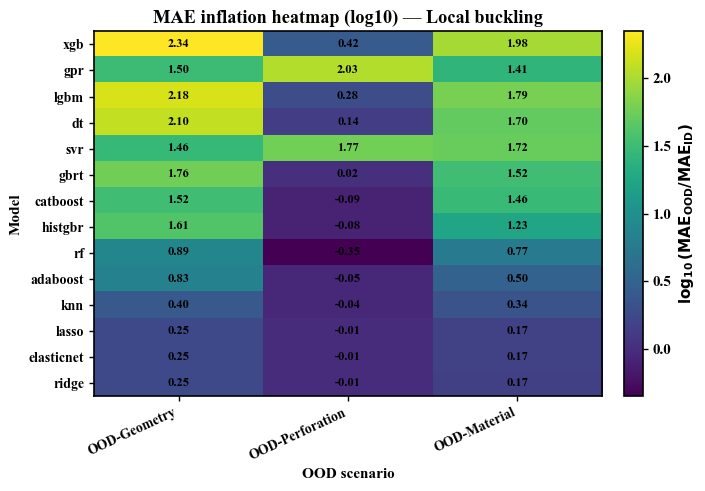

Saved: figures/heatmap_inflation_log10_M_LB.png


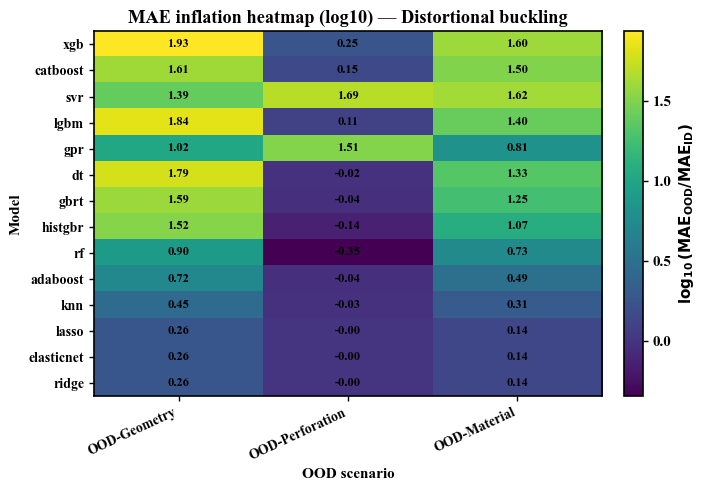

Saved: figures/heatmap_inflation_log10_M_DB.png


In [58]:
# ====== Heatmap: MAE inflation (models × scenarios) ======
import os
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

os.makedirs("figures", exist_ok=True)
os.makedirs("outputs", exist_ok=True)

# ---------- Style ----------
mpl.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 11,
    "font.weight": "bold",
    "axes.labelweight": "bold",
    "axes.titleweight": "bold",
    "axes.edgecolor": "black",
    "axes.linewidth": 1.2,
    "xtick.major.width": 1.0,
    "ytick.major.width": 1.0,
})

# ---------- Load required tables ----------
ood = pd.read_csv("outputs/ood_results_all_models.csv")
id_lb = pd.read_csv("outputs/id_results_M_LB.csv")
id_db = pd.read_csv("outputs/id_results_M_DB.csv")

# unify model column naming
if "Model" in id_lb.columns and "model" not in id_lb.columns:
    id_lb = id_lb.rename(columns={"Model": "model"})
if "Model" in id_db.columns and "model" not in id_db.columns:
    id_db = id_db.rename(columns={"Model": "model"})

# ---------- Build ID MAE table ----------
id_mae = pd.concat([
    id_lb[["model", "MAE"]].assign(Target="M_LB"),
    id_db[["model", "MAE"]].assign(Target="M_DB"),
], ignore_index=True).rename(columns={"model": "Model", "MAE": "MAE_ID"})

# ---------- Build inflation table ----------
ood_mae = ood[["Target", "Model", "Scenario", "MAE"]].rename(columns={"MAE": "MAE_OOD"})
infl = ood_mae.merge(id_mae, on=["Target", "Model"], how="left")

eps = 1e-12
infl["Inflation_MAE"] = infl["MAE_OOD"] / np.maximum(infl["MAE_ID"], eps)

# scenario order
scen_order = ["OOD-Geometry", "OOD-Perforation", "OOD-Material"]
scen_present = [s for s in scen_order if s in infl["Scenario"].unique()]
extras = [s for s in infl["Scenario"].unique() if s not in scen_present]
scen_present += sorted(extras)

MODE_LABEL = {"M_LB": "Local buckling", "M_DB": "Distortional buckling"}

def heatmap_for_target(tgt):
    sub = infl[infl["Target"] == tgt].copy()

    # model order: by ID MAE (best first)
    id_order = (
        id_mae[id_mae["Target"] == tgt]
        .sort_values("MAE_ID")["Model"]
        .astype(str).tolist()
    )

    piv = sub.pivot_table(index="Model", columns="Scenario", values="Inflation_MAE", aggfunc="first")
    piv = piv.reindex(columns=scen_present)
    piv = piv.reindex(index=[m for m in id_order if m in piv.index])

    # log10 inflation for visibility
    mat = np.log10(piv.values.astype(float))

    fig, ax = plt.subplots(figsize=(7.2, max(3.4, 0.36 * len(piv.index))))
    im = ax.imshow(mat, aspect="auto")  # default colormap (no explicit colors)

    ax.set_xticks(np.arange(len(piv.columns)))
    ax.set_xticklabels(piv.columns, rotation=25, ha="right")
    ax.set_yticks(np.arange(len(piv.index)))
    ax.set_yticklabels(piv.index)

    ax.set_title(f"MAE inflation heatmap (log10) — {MODE_LABEL.get(tgt, tgt)}")
    ax.set_xlabel("OOD scenario")
    ax.set_ylabel("Model")

    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(r"$\log_{10}(\mathrm{MAE}_{\mathrm{OOD}}/\mathrm{MAE}_{\mathrm{ID}})$", fontweight="bold")

    # annotate cells (2 decimals)
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            v = mat[i, j]
            if np.isfinite(v):
                ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=9, fontweight="bold")

    ax.tick_params(axis="both", labelsize=10)
    for lab in ax.get_xticklabels() + ax.get_yticklabels():
        lab.set_fontweight("bold")

    fig.tight_layout()
    out = f"figures/heatmap_inflation_log10_{tgt}.png"
    fig.savefig(out, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", out)

# ----- Generate both heatmaps -----
heatmap_for_target("M_LB")
heatmap_for_target("M_DB")

In [59]:
# ====== SHAP: ID vs OOD (XGBoost only) ======
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.base import clone

# pip install shap  (if needed)
import shap

os.makedirs("figures", exist_ok=True)

XGB_KEY = "xgb"   # change if your model key is "XGBoost" etc.

def get_preprocessor(pipe):
    # your pipelines used either "preprocessor" or "pre"
    if "preprocessor" in pipe.named_steps:
        return pipe.named_steps["preprocessor"]
    if "pre" in pipe.named_steps:
        return pipe.named_steps["pre"]
    raise KeyError("Pipeline has no preprocessor step named 'preprocessor' or 'pre'.")

def get_design_matrix_and_names(pipe, X):
    pre = get_preprocessor(pipe)
    Xt = pre.transform(X)
    try:
        feat_names = pre.get_feature_names_out()
    except Exception:
        feat_names = np.array(X_cols, dtype=str)
    return Xt, feat_names

def shap_plots_for_split(model, Xt, feat_names, title_prefix, out_prefix):
    explainer = shap.TreeExplainer(model)
    shap_vals = explainer.shap_values(Xt)

    # Beeswarm
    plt.figure(figsize=(8, 5))
    shap.summary_plot(shap_vals, Xt, feature_names=feat_names, show=False)
    plt.title(f"{title_prefix} — SHAP summary (beeswarm)", fontweight="bold")
    plt.tight_layout()
    plt.savefig(f"figures/{out_prefix}_beeswarm.png", dpi=300, bbox_inches="tight")
    plt.show()

    # Bar (mean |SHAP|)
    plt.figure(figsize=(8, 5))
    shap.summary_plot(shap_vals, Xt, feature_names=feat_names, plot_type="bar", show=False)
    plt.title(f"{title_prefix} — SHAP global importance (bar)", fontweight="bold")
    plt.tight_layout()
    plt.savefig(f"figures/{out_prefix}_bar.png", dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", f"figures/{out_prefix}_beeswarm.png")
    print("Saved:", f"figures/{out_prefix}_bar.png")

In [60]:
# ====== OOD masks (Geometry / Perforation / Material) ======
is_geom, meta_geom = ood_split_geometry(df, q=0.15)
is_perf, meta_perf = ood_split_group(df, "Lsl")
is_mat,  meta_mat  = ood_split_group(df, "Fy")

OOD = {
    "OOD-Geometry": is_geom,
    "OOD-Perforation": is_perf,
    "OOD-Material": is_mat,
}

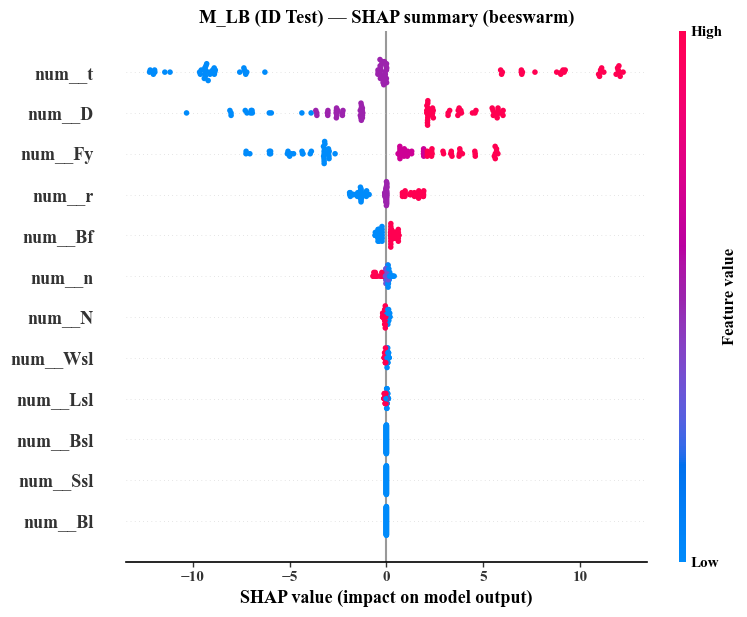

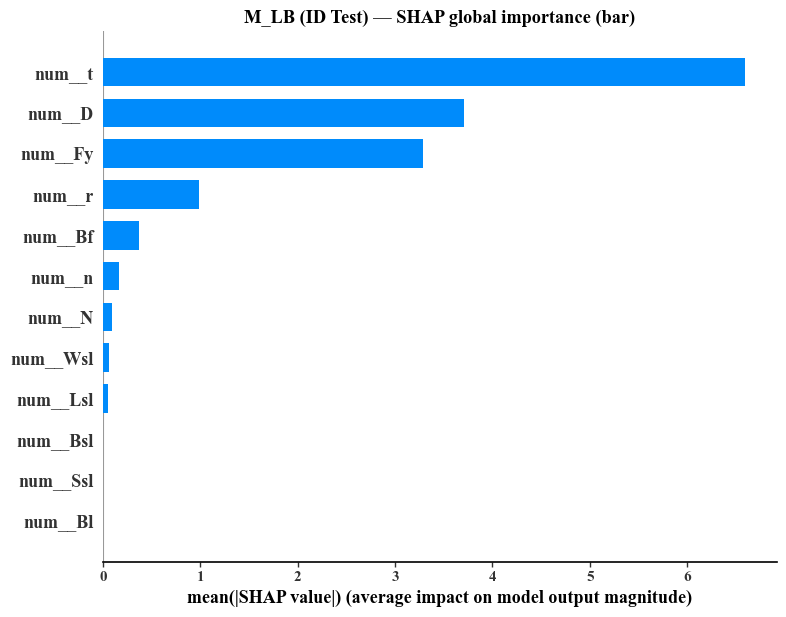

Saved: figures/shap_M_LB_ID_beeswarm.png
Saved: figures/shap_M_LB_ID_bar.png


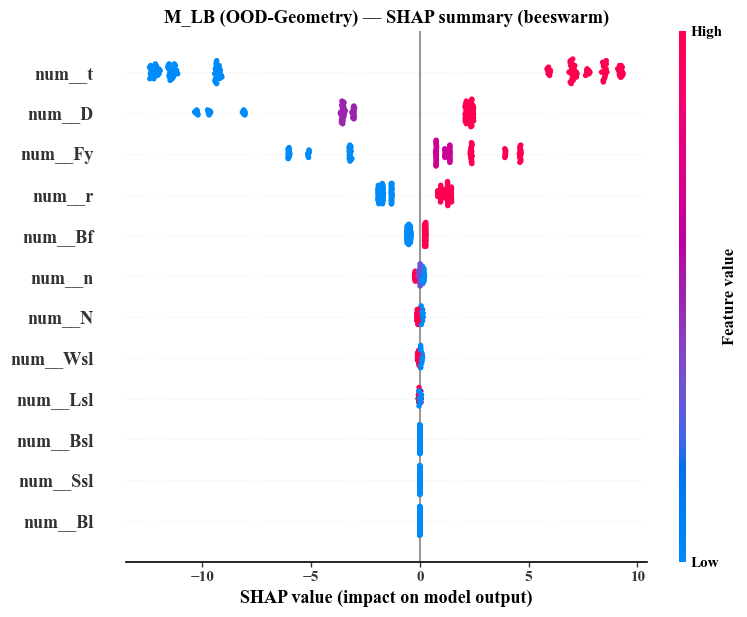

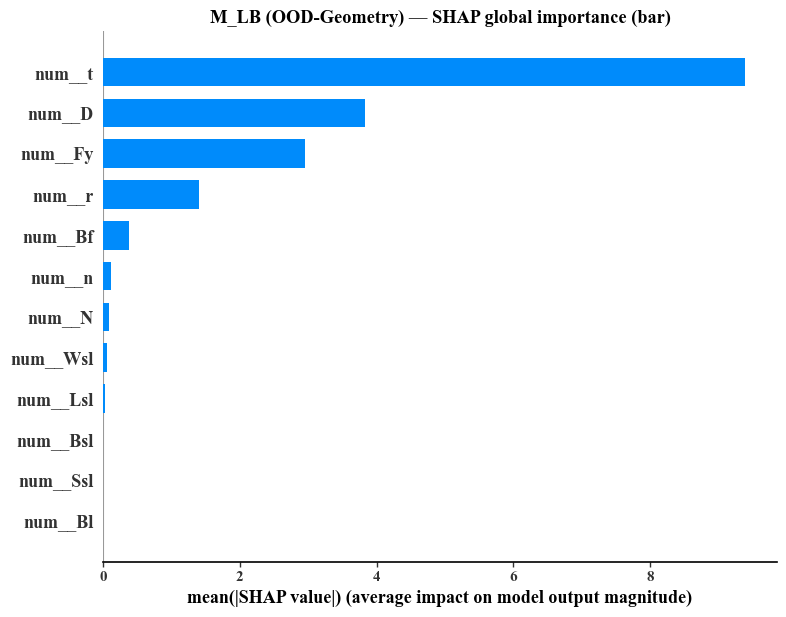

Saved: figures/shap_M_LB_OOD_Geometry_beeswarm.png
Saved: figures/shap_M_LB_OOD_Geometry_bar.png


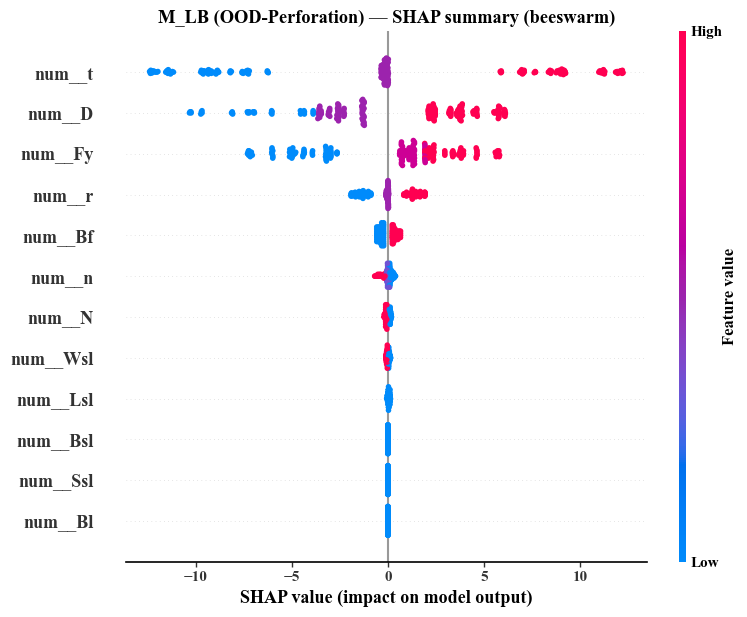

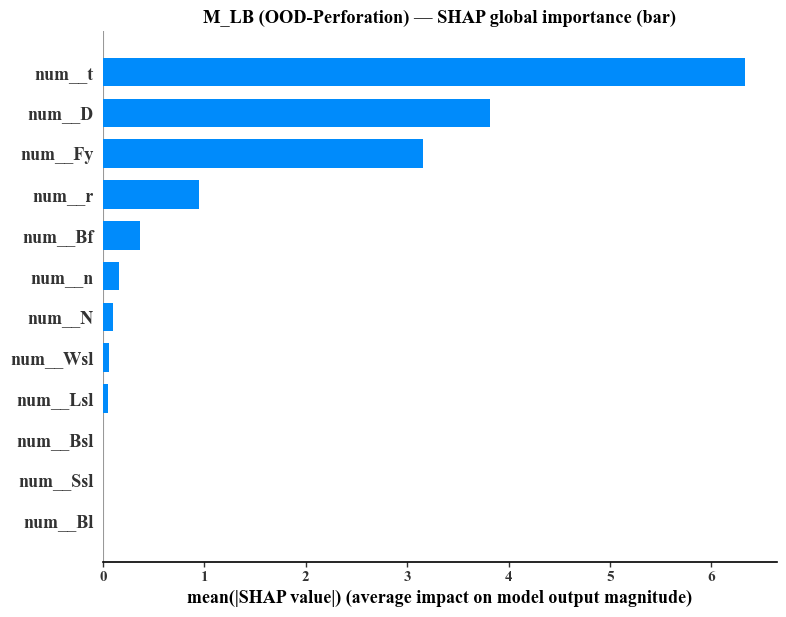

Saved: figures/shap_M_LB_OOD_Perforation_beeswarm.png
Saved: figures/shap_M_LB_OOD_Perforation_bar.png


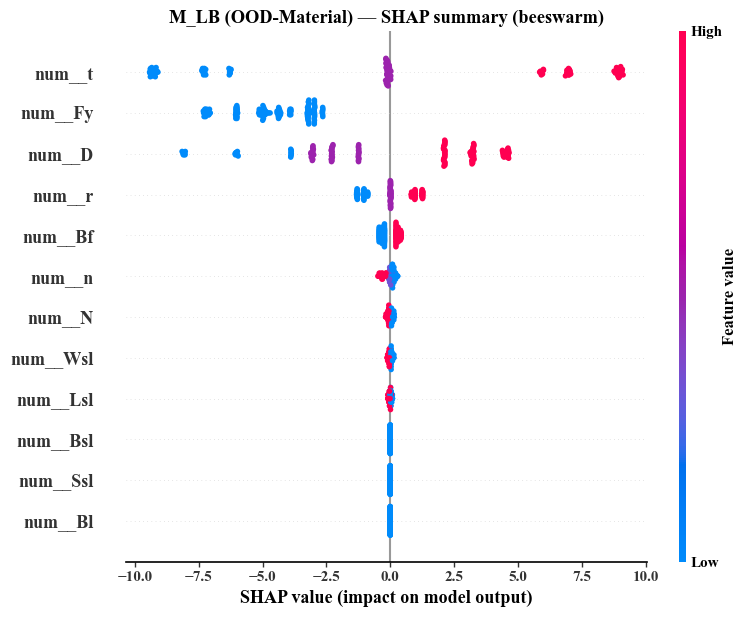

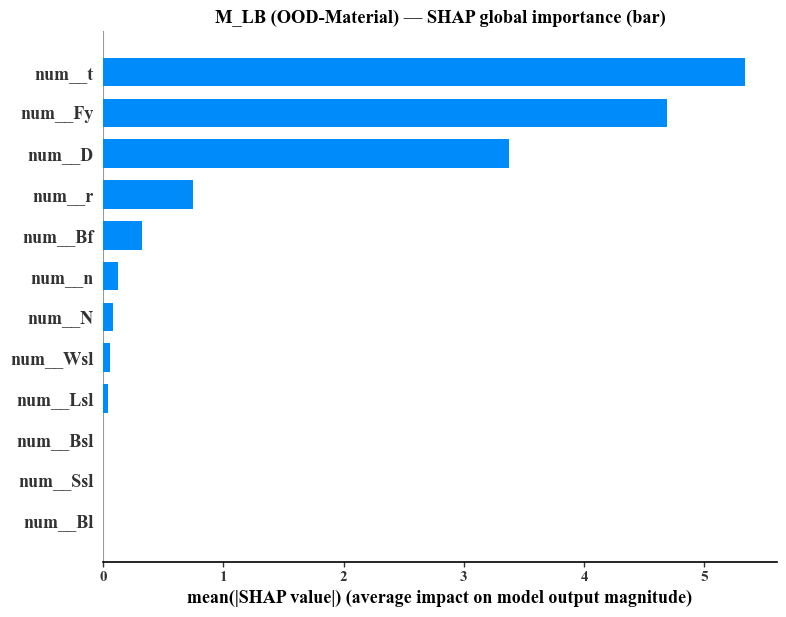

Saved: figures/shap_M_LB_OOD_Material_beeswarm.png
Saved: figures/shap_M_LB_OOD_Material_bar.png


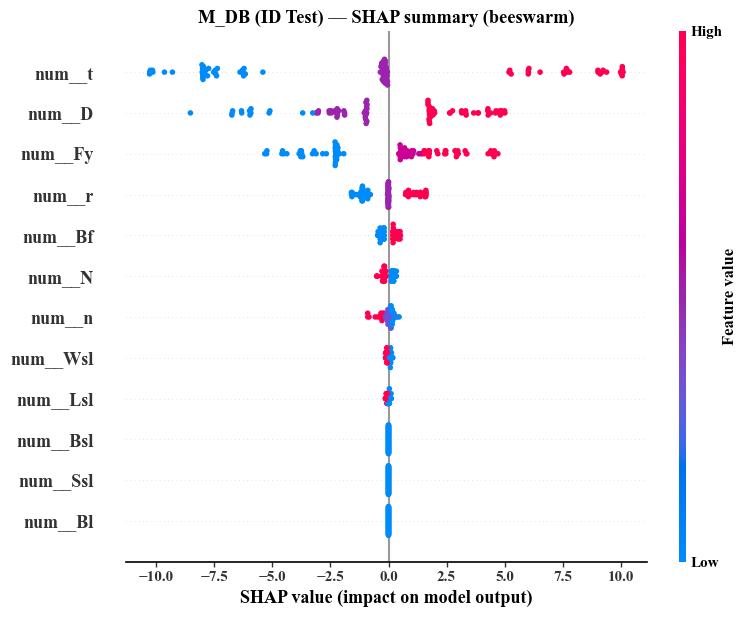

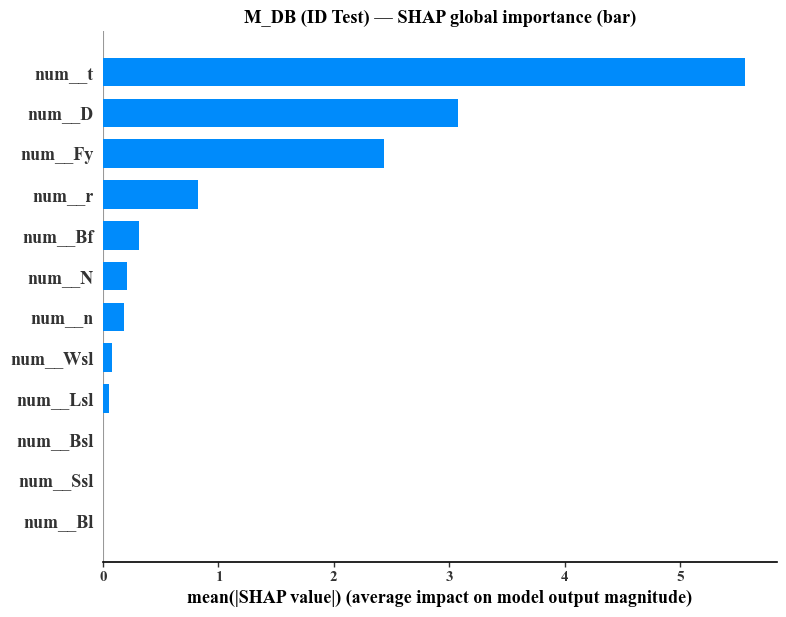

Saved: figures/shap_M_DB_ID_beeswarm.png
Saved: figures/shap_M_DB_ID_bar.png


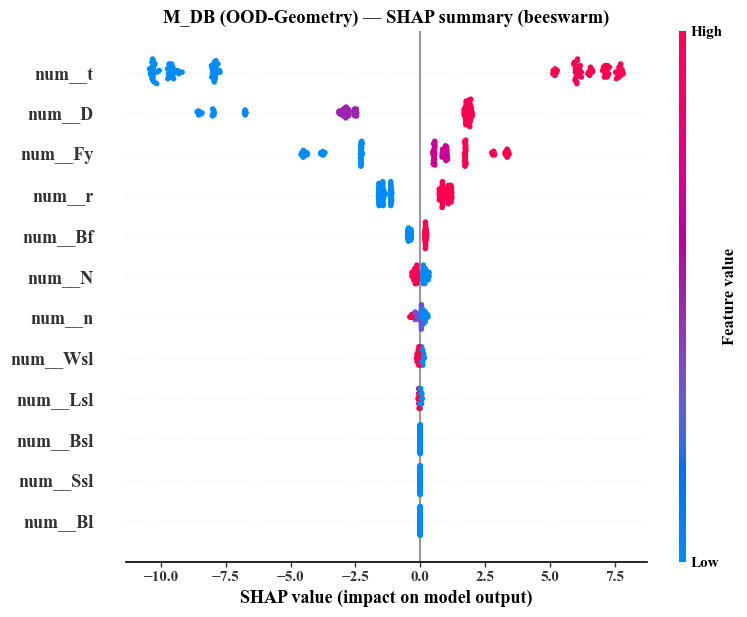

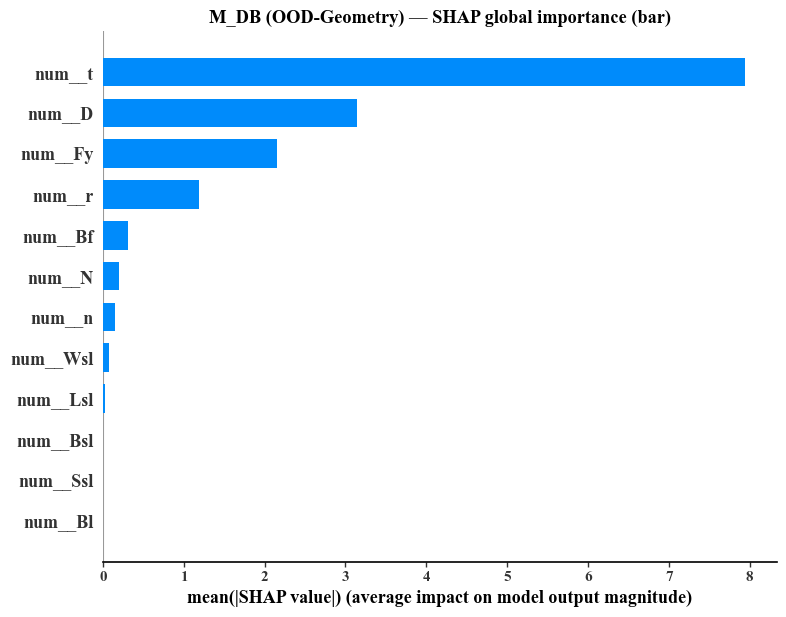

Saved: figures/shap_M_DB_OOD_Geometry_beeswarm.png
Saved: figures/shap_M_DB_OOD_Geometry_bar.png


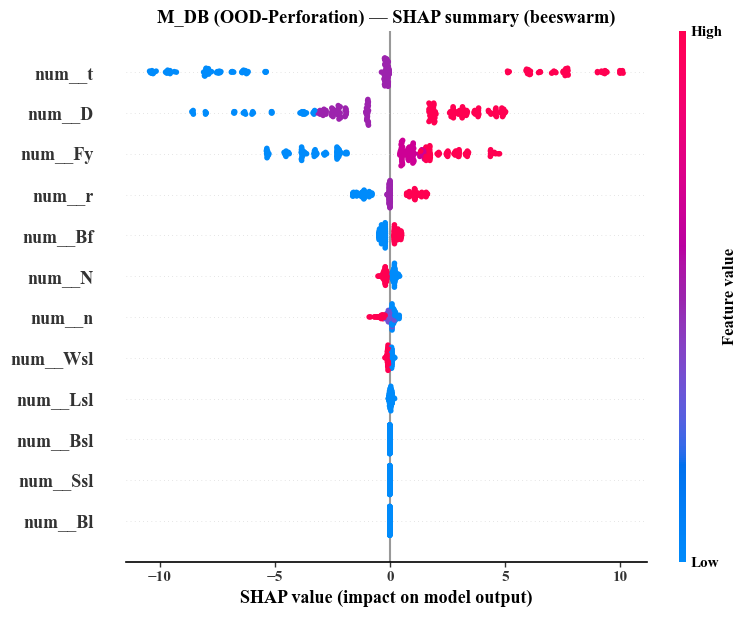

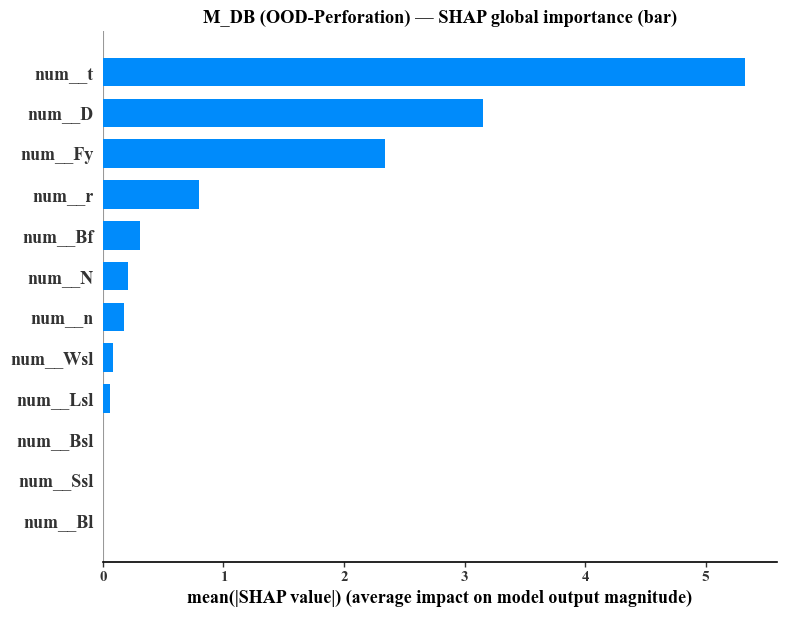

Saved: figures/shap_M_DB_OOD_Perforation_beeswarm.png
Saved: figures/shap_M_DB_OOD_Perforation_bar.png


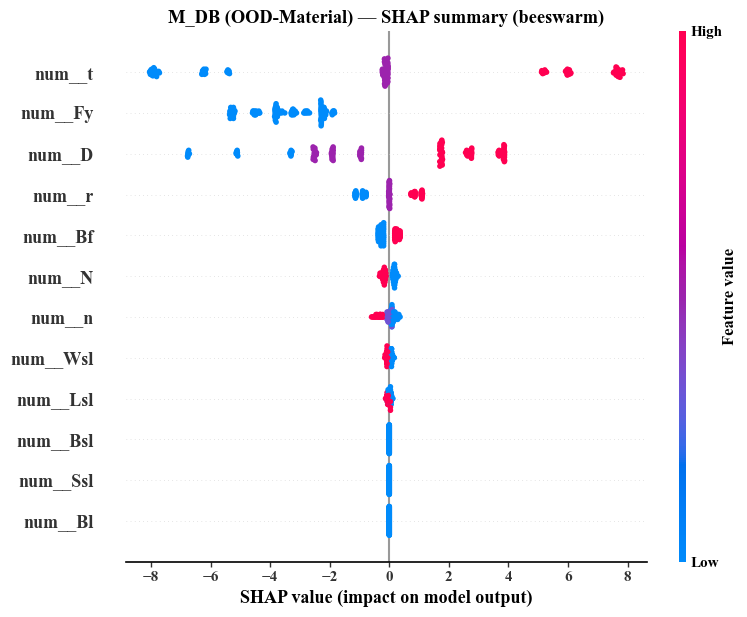

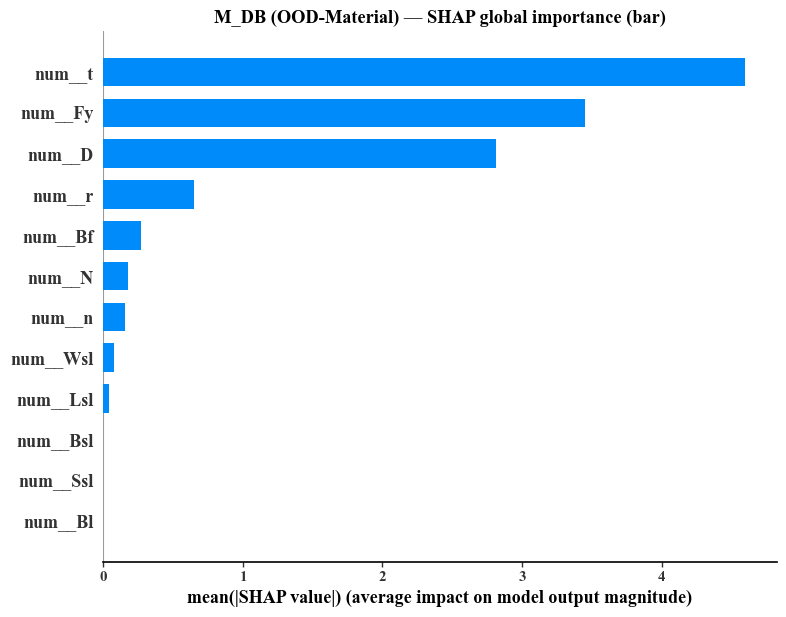

Saved: figures/shap_M_DB_OOD_Material_beeswarm.png
Saved: figures/shap_M_DB_OOD_Material_bar.png


In [61]:
# ====== Run SHAP: ID vs OOD for each target ======
for t in targets:
    # get fixed ID split
    splits = id_results[t]["splits"]
    X_train = splits["X_train"]
    X_idtest = splits["X_test"]
    y_train = splits["y_train"]

    # get XGB pipeline and fit on ID train (clone so we don't overwrite stored)
    if XGB_KEY not in id_results[t]["models"]:
        raise ValueError(f"XGB_KEY='{XGB_KEY}' not found in id_results[{t}]['models'].")

    pipe0 = id_results[t]["models"][XGB_KEY]
    pipe = clone(pipe0)
    pipe.fit(X_train, y_train)

    model = pipe.named_steps["model"]

    # ---------- ID SHAP ----------
    Xt_id, feat_names = get_design_matrix_and_names(pipe, X_idtest)
    shap_plots_for_split(
        model, Xt_id, feat_names,
        title_prefix=f"{t} (ID Test)",
        out_prefix=f"shap_{t}_ID"
    )

    # ---------- OOD SHAP ----------
    for scen, mask in OOD.items():
        X_ood = df.loc[mask, X_cols].copy()
        Xt_ood, _ = get_design_matrix_and_names(pipe, X_ood)

        shap_plots_for_split(
            model, Xt_ood, feat_names,
            title_prefix=f"{t} ({scen})",
            out_prefix=f"shap_{t}_{scen.replace('-','_')}"
        )

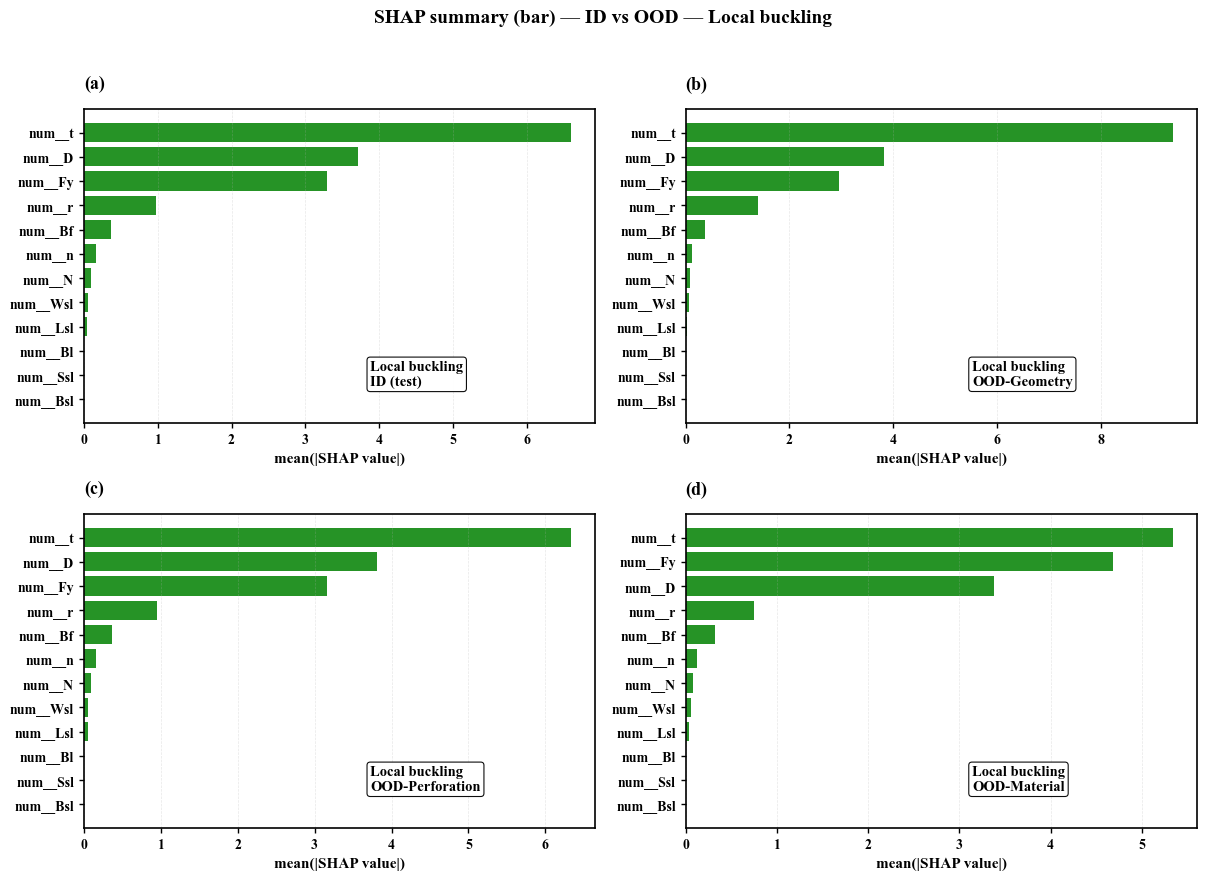

Saved: figures/shap_summary_2x2_M_LB.png


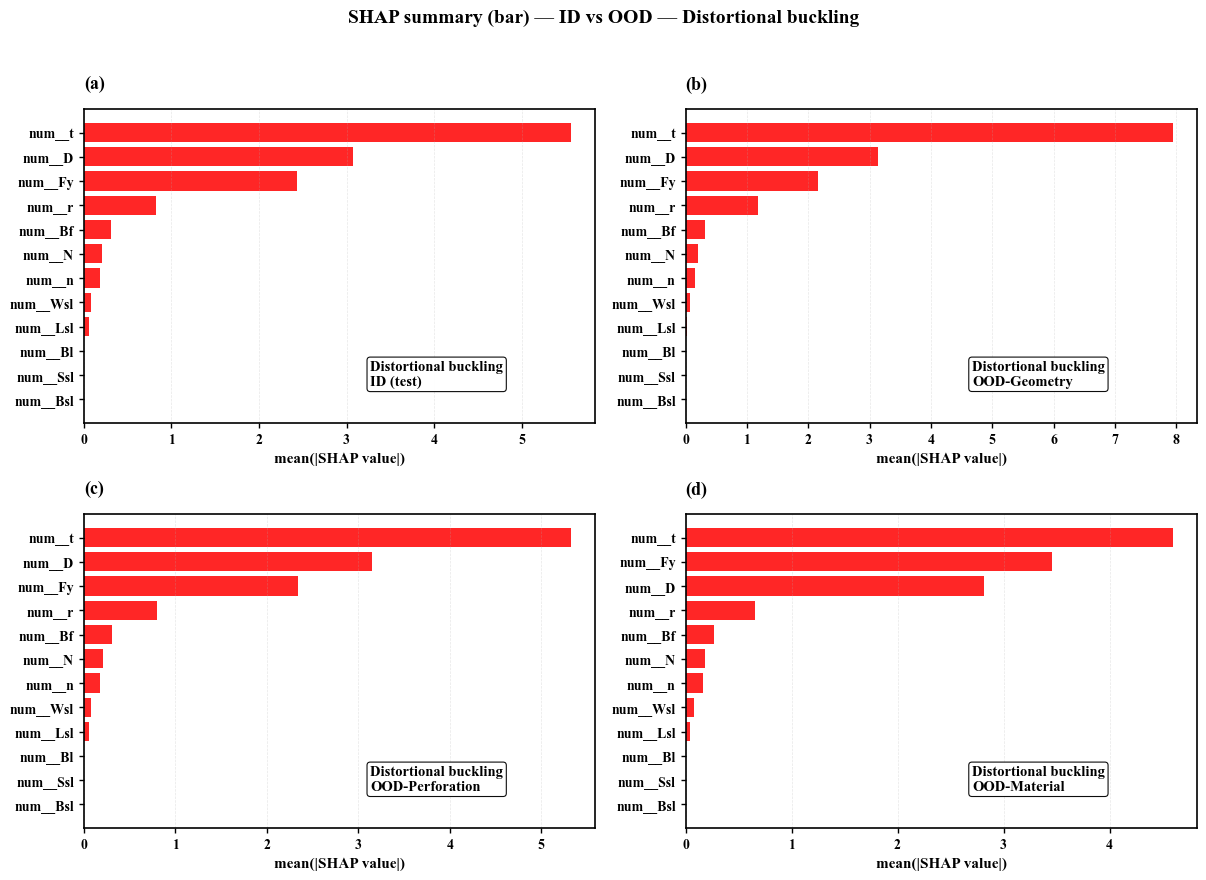

Saved: figures/shap_summary_2x2_M_DB.png


In [69]:
# ====== SHAP (XGB) — summary BAR only, 2×2 grid per target
# Panels: (a) ID-Test, (b) OOD-Geometry, (c) OOD-Perforation, (d) OOD-Material
# Color: green=Local buckling (M_LB), red=Distortional buckling (M_DB)

import os
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from sklearn.base import clone
import shap

os.makedirs("figures", exist_ok=True)

# ---- settings ----
XGB_KEY = "xgb"          # change if your key differs
TOPK = 12                # number of top features to show in each panel
SCENARIOS = ["ID", "OOD-Geometry", "OOD-Perforation", "OOD-Material"]

MODE_LABEL = {"M_LB": "Local buckling", "M_DB": "Distortional buckling"}
MODE_COLOR = {"M_LB": "green", "M_DB": "red"}

mpl.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 11,
    "font.weight": "bold",
    "axes.labelweight": "bold",
    "axes.titleweight": "bold",
    "axes.edgecolor": "black",
    "axes.linewidth": 1.2,
    "xtick.major.width": 1.0,
    "ytick.major.width": 1.0,
})

def panel_label(i):
    return f"({chr(ord('a') + i)})"

def get_preprocessor(pipe):
    if "preprocessor" in pipe.named_steps:
        return pipe.named_steps["preprocessor"]
    if "pre" in pipe.named_steps:
        return pipe.named_steps["pre"]
    raise KeyError("Pipeline has no 'preprocessor' or 'pre' step.")

def transform_with_names(pipe, X):
    pre = get_preprocessor(pipe)
    Xt = pre.transform(X)
    try:
        names = pre.get_feature_names_out()
        names = np.array(names, dtype=str)
    except Exception:
        names = np.array(X_cols, dtype=str)
    return Xt, names

def shap_mean_abs(explainer, Xt):
    sv = explainer.shap_values(Xt)
    sv = np.asarray(sv)
    return np.mean(np.abs(sv), axis=0)

def get_ood_masks():
    # Uses your existing utilities: ood_split_geometry, ood_split_group
    is_geom, _ = ood_split_geometry(df, q=0.15)
    is_perf, _ = ood_split_group(df, "Lsl")
    is_mat,  _ = ood_split_group(df, "Fy")
    return {
        "OOD-Geometry": is_geom,
        "OOD-Perforation": is_perf,
        "OOD-Material": is_mat
    }

OOD_MASKS = get_ood_masks()

def plot_shap_2x2_for_target(tgt):
    if XGB_KEY not in id_results[tgt]["models"]:
        raise ValueError(f"XGB_KEY='{XGB_KEY}' not found in id_results[{tgt}]['models'].")

    # Fit XGB on fixed ID train split (same trained model used for all panels)
    splits = id_results[tgt]["splits"]
    X_train = splits["X_train"]
    y_train = splits["y_train"]
    X_idtest = splits["X_test"]

    pipe = clone(id_results[tgt]["models"][XGB_KEY])
    pipe.fit(X_train, y_train)

    model = pipe.named_steps["model"]
    explainer = shap.TreeExplainer(model)

    # feature names from preprocessor
    _, feat_names = transform_with_names(pipe, X_train)

    # ----- collect mean|SHAP| for ID and each OOD test set -----
    scen_data = []

    # ID test set
    Xt_id, _ = transform_with_names(pipe, X_idtest)
    scen_data.append(("ID (test)", shap_mean_abs(explainer, Xt_id)))

    # OOD sets
    for scen in ["OOD-Geometry", "OOD-Perforation", "OOD-Material"]:
        mask = OOD_MASKS[scen]
        X_s = df.loc[mask, X_cols].copy()
        Xt_s, _ = transform_with_names(pipe, X_s)
        scen_data.append((scen, shap_mean_abs(explainer, Xt_s)))

    # Choose TOPK features based on max mean|SHAP| across all 4 panels
    M = np.vstack([v for _, v in scen_data])
    score = np.max(M, axis=0)
    top_idx = np.argsort(score)[::-1][:TOPK]

    # ----- 2×2 grid -----
    fig, axes = plt.subplots(2, 2, figsize=(12.2, 8.6))
    axes = axes.ravel()
    color = MODE_COLOR.get(tgt, "black")

    for i, (scen_name, mean_abs) in enumerate(scen_data):
        ax = axes[i]
        vals = mean_abs[top_idx]
        names = feat_names[top_idx]

        # sort within panel (ascending for barh)
        order = np.argsort(vals)
        vals = vals[order]
        names = names[order]

        ax.barh(np.arange(len(vals)), vals, color=color, alpha=0.85)
        ax.set_yticks(np.arange(len(vals)))
        ax.set_yticklabels(names)

        ax.grid(axis="x", linestyle="--", linewidth=0.5, alpha=0.30)
        ax.set_xlabel("mean(|SHAP value|)")

        # panel label (a)(b)(c)(d)
        ax.text(0.00, 1.05, panel_label(i), transform=ax.transAxes,
                ha="left", va="bottom", fontsize=13, fontweight="bold")

        # top-left box
        ax.text(0.56, 0.2, f"{MODE_LABEL.get(tgt, tgt)}\n{scen_name}",
                transform=ax.transAxes, ha="left", va="top",
                fontsize=10.5, fontweight="bold",
                bbox=dict(boxstyle="round,pad=0.22", fc="white", ec="black", lw=0.8, alpha=0.95))

        # bold ticks
        ax.tick_params(axis="both", labelsize=10, width=1.0, colors="black")
        for lab in ax.get_xticklabels() + ax.get_yticklabels():
            lab.set_fontweight("bold")

    fig.suptitle(f"SHAP summary (bar) — ID vs OOD — {MODE_LABEL.get(tgt, tgt)}",
                 fontsize=14, fontweight="bold", y=1.02)

    fig.tight_layout()
    out = f"figures/shap_summary_2x2_{tgt}.png"
    fig.savefig(out, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", out)

# ---- Run for both targets ----
plot_shap_2x2_for_target("M_LB")  # green
plot_shap_2x2_for_target("M_DB")  # red